# Environmental Sound Classification — UrbanSound8K
**Alexandria University · Faculty of Engineering · Computer & Systems Engineering**  
**Course:** CSE Pattern Recognition  &emsp; **Due:** Wed, Jun 3 2026

---


---
## 1 · Overview

### 1.1 What this notebook does
This notebook builds an **Environmental Sound Classification (ESC)** system on the [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html) dataset, which contains **8 732 labelled audio clips** drawn from 10 urban sound categories.  
The goal is to push well above the 65 % GRU baseline by combining richer features, stronger regularisation, and an improved model architecture — while staying within the constraint of **GRU-based and CNN-GRU-based** models only.

---

### 1.2 Dataset at a glance

| Property | Value |
|---|---|
| Total clips | 8 732 |
| Classes | 10 |
| Max clip length | 4 seconds |
| Sample rate | 22 050 Hz |
| Pre-defined folds | 10 (fold-aware cross-validation) |

**Classes:** `air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`

**Fold splits used in this notebook (per the assignment spec):**

| Split | Folds | Approx. clips |
|---|---|---|
| Train | 1 – 6 | ~5 435 |
| Validation | 7 – 8 | ~1 644 |
| Test | 9 – 10 | ~1 653 |

---

### 1.3 Pipeline overview

```
Raw Audio (WAV)
      │
      ▼
 Audio Loading & Pre-processing (resample → 22 050 Hz, pad/trim → 4 s)
      │
      ├──► Data Exploration & Visualisation
      │        (fold counts, class distribution, waveforms,
      │         Mel spectrograms, Gammatone spectrograms / GFCCs)
      │
      ▼
 Feature Extraction  (565-dim per frame)
      ├─ Mel-spectrogram   (128)
      ├─ MFCCs             ( 40)
      ├─ Δ-MFCCs           ( 40)
      ├─ ΔΔ-MFCCs          ( 40)
      ├─ RMS Energy        (  1)
      ├─ Chroma STFT       ( 12)
      ├─ Spectral Contrast (  6)
      ├─ ZCR               (  1)
      ├─ Spectral Rolloff  (  1)
      ├─ GFCCs (Gammatone) ( 40)  ← NEW
      ├─ Multi-scale Mel   (128)  ← NEW (short hop)
      └─ Multi-scale Mel   (128)  ← NEW (long  hop)
      │
      ▼
 Normalisation (global mean / std over training set)
 Caching  (save .npy per clip → fast DataLoader)
      │
      ▼
 Augmentation (SpecAugment · Gaussian noise · Amplitude scaling · Mixup)
      │
      ▼
 Model Training
      ├─ EnhancedGRUClassifier    (Bi-GRU + multi-head attention)
      └─ DeepCNNGRUClassifier     (Residual CNN + SE blocks + Bi-GRU)
      │
      ▼
 Evaluation
      ├─ Learning curves & HP comparison
      ├─ Validation confusion matrices (all configs)
      └─ Test confusion matrix + per-class accuracy bar chart
```

---

### 1.4 Key improvements over the baseline

| Area | Baseline | This notebook |
|---|---|---|
| Features | 123-dim | **565-dim** (adds GFCCs, multi-scale Mel, Δ/ΔΔ MFCCs, ZCR, Rolloff) |
| Normalisation | Per-sample z-score | **Global** mean / std from training set |
| GRU model | Single-head attention | **Multi-head** (4 heads) + residual projection |
| CNN-GRU | Simple 2-layer CNN | **Deep residual CNN** (3 ResConv blocks, SE attention) |
| Loss | CrossEntropy | **Label-smoothed** CrossEntropy (ε = 0.1) |
| Augmentation | 4 basic ops | + **Mixup** (α = 0.4) + stronger SpecAugment |
| Scheduler | Cosine | Cosine **+ linear warmup** + ReduceLROnPlateau fallback |
| Epochs | 50 max | **100** max (patience = 15) |

---

> **Note:** No code is executed in this section — it is a conceptual and structural guide for the notebook.


---
## 2 · Dependencies and Data Installation & Extraction

### 2.1 Explanation
This section handles everything needed before any audio is touched:

1. **Package installation** — all Python libraries required by the pipeline.  
   Key packages:
   - `librosa` — audio loading, feature extraction (Mel, MFCC, Chroma, Contrast, ZCR, Rolloff)
   - `gammatone` — Gammatone filterbank for GFCC computation (auditory-model features)
   - `torch / torchaudio` — deep learning (CUDA build for Colab / CPU fallback locally)
   - `scikit-learn` — metrics (accuracy, F1, confusion matrix)
   - `tqdm` — progress bars for feature extraction loops

2. **Dataset download** — the UrbanSound8K `.tar.gz` is downloaded from the official mirror (~6 GB).

3. **Extraction** — the archive is unpacked to `/content/UrbanSound8K/`, creating the `audio/` folder (10 sub-folders, one per fold) and the `metadata/UrbanSound8K.csv` file.


In [2]:
# ── 2a · Package installation ─────────────────────────────────────────────────
# Uncomment the block below on a fresh Colab runtime.
# !pip install -q librosa ipywidgets gammatone scikit-learn tqdm

import sys, platform

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    # Ensure CUDA-enabled PyTorch is present
    subprocess.run(["pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"],
                   capture_output=True)
    subprocess.run(["pip", "install", "torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cu121",
                    "-q"],
                   capture_output=True)
    subprocess.run(["pip", "install", "-q", "librosa", "ipywidgets",
                    "gammatone", "scikit-learn", "tqdm"], capture_output=True)
    print("Colab: CUDA PyTorch + audio packages installed.")
else:
    !pip install gammatone
    print(f"Local ({platform.system()}): assuming packages already installed.")
    print("If not, run: pip install torch torchvision torchaudio librosa gammatone scikit-learn tqdm")

print("Done.")


Local (Linux): assuming packages already installed.
If not, run: pip install torch torchvision torchaudio librosa gammatone scikit-learn tqdm
Done.


In [3]:
# ── 2b · Download UrbanSound8K ────────────────────────────────────────────────
# Official mirror (~6 GB).  Skip if already present.
import os

ARCHIVE = '/urbansound8k.tar.gz'
if not os.path.exists(ARCHIVE):
    print("Downloading UrbanSound8K (~6 GB) — this takes a few minutes …")
    os.system(f'wget -q -O {ARCHIVE} "https://goo.gl/8hY5ER"')
    print("Download complete.")
else:
    print("Archive already present — skipping download.")


Download complete.


In [4]:
# ── 2c · Extract archive ──────────────────────────────────────────────────────
import tarfile
from pathlib import Path

EXTRACT_DIR = Path('/content')
DATA_ROOT   = EXTRACT_DIR / 'UrbanSound8K'

if not DATA_ROOT.exists():
    print("Extracting …")
    with tarfile.open(ARCHIVE, 'r:gz') as tar:
        tar.extractall(str(EXTRACT_DIR))
    print("Extraction complete.")
else:
    print("Dataset already extracted — skipping.")

# Quick sanity check
audio_folds = sorted([p.name for p in (DATA_ROOT / 'audio').iterdir() if p.is_dir()])
print(f"\nAudio folds found: {audio_folds}")
print(f"Metadata: {(DATA_ROOT / 'metadata' / 'UrbanSound8K.csv').exists()}")


Extracting …


/tmp/ipykernel_58/2419860697.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(str(EXTRACT_DIR))


Extraction complete.

Audio folds found: ['fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9']
Metadata: True


---
## 3 · Imports & Global Configuration

All Python imports and dataset-wide constants are centralised here so that every subsequent cell can rely on them.  
Setting a fixed random seed at this point ensures fully reproducible results across NumPy, PyTorch, and the Python `random` module.


In [5]:
# ── 3 · Imports & Global Configuration ───────────────────────────────────────
import os, sys, time, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from scipy.fftpack import dct as _scipy_dct
import gammatone.fftweight as _gtfw
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('/content/UrbanSound8K')
AUDIO_DIR  = DATA_ROOT / 'audio'
META_FILE  = DATA_ROOT / 'metadata' / 'UrbanSound8K.csv'
CACHE_DIR  = Path('feature_cache_v3')
OUTPUT_DIR = Path('outputs_v3')
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
TRAIN_FOLDS  = [1, 2, 3, 4, 5, 6]
VAL_FOLDS    = [7, 8]
TEST_FOLDS   = [9, 10]
NUM_CLASSES  = 10
CLASS_NAMES  = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
                'drilling', 'engine_idling', 'gun_shot', 'jackhammer',
                'siren', 'street_music']

# ── Audio constants ───────────────────────────────────────────────────────────
SR         = 22050
DURATION   = 4.0
N_SAMPLES  = int(SR * DURATION)   # 88 200
N_FFT      = 1024
HOP_LENGTH = 512
N_MELS     = 128
N_MFCC     = 40
N_CHROMA   = 12
N_CONTRAST = 6

# ── New-feature constants ─────────────────────────────────────────────────────
N_GTFB    = 64    # Gammatone filterbank channels
N_GFCC    = 40    # GFCCs retained after DCT
HOP_SHORT = 256   # finer temporal resolution  (~11.6 ms / frame)
HOP_LONG  = 1024  # coarser temporal resolution (~46.4 ms / frame)

FEATURE_DIM = (N_MELS + N_MFCC*3 + 1 + N_CHROMA + N_CONTRAST + 1 + 1
               + N_GFCC + N_MELS + N_MELS)   # = 565
print(f"Feature dimension: {FEATURE_DIM}")

# ── Load metadata ─────────────────────────────────────────────────────────────
meta = pd.read_csv(META_FILE)
print(f"Total clips: {len(meta)}   Classes: {meta['class'].nunique()}   Folds: {meta['fold'].nunique()}")


Device: cuda
Feature dimension: 565
Total clips: 8732   Classes: 10   Folds: 10


---
## 4 · Data Exploration and Visualisation

### 4.1 Explanation
Before building any model it is essential to understand the dataset's structure.  
We examine:

1. **Fold counts** — are the ~874 clips-per-fold roughly balanced across folds?  Imbalance here could distort validation metrics.
2. **Class distribution** — do all 10 classes appear with similar frequency?  Class imbalance affects both training dynamics and the choice of evaluation metric (macro-F1 is used here precisely because it is insensitive to class size).
3. **Waveforms** — temporal amplitude envelopes.  Impulsive sounds (gun-shot) look very different from sustained textures (engine-idling), giving an intuition for why temporal features (Δ-MFCCs) matter.
4. **Mel spectrograms** — 2-D time-frequency energy maps using a perceptually-spaced frequency axis.  They reveal harmonic structure, noise-floor characteristics and temporal modulation patterns.
5. **Gammatone Filterbank spectrogram** — the ERB-spaced auditory filterbank output that is the basis for GFCCs.  Visualising it alongside the Mel spectrogram illustrates the resolution differences, particularly at low frequencies where the Gammatone bank allocates more channels.


In [6]:
# ── 4a · Audio loading helper ────────────────────────────────────────────────
def load_audio(filepath, sr=SR, duration=DURATION):
    """Load, resample, and pad/trim to exactly `duration` seconds."""
    y, _ = librosa.load(str(filepath), sr=sr, mono=True, duration=duration)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)), mode='constant')
    else:
        y = y[:target]
    return y.astype(np.float32)


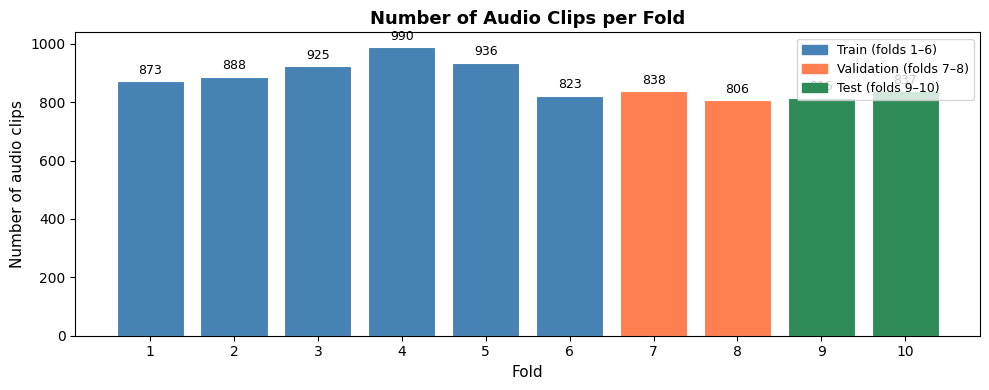

Saved → fold_distribution.png


In [7]:
# ── 4b · Clips per fold (bar chart) ──────────────────────────────────────────
fold_counts = meta['fold'].value_counts().sort_index()
split_colors = {f: ('steelblue' if f in TRAIN_FOLDS
                    else ('coral' if f in VAL_FOLDS else 'seagreen'))
                for f in fold_counts.index}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(fold_counts.index, fold_counts.values,
              color=[split_colors[f] for f in fold_counts.index],
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('Number of audio clips', fontsize=11)
ax.set_title('Number of Audio Clips per Fold', fontsize=13, fontweight='bold')
ax.set_xticks(fold_counts.index)

from matplotlib.patches import Patch
legend_handles = [Patch(color='steelblue', label='Train (folds 1–6)'),
                  Patch(color='coral',     label='Validation (folds 7–8)'),
                  Patch(color='seagreen',  label='Test (folds 9–10)')]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fold_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → fold_distribution.png")


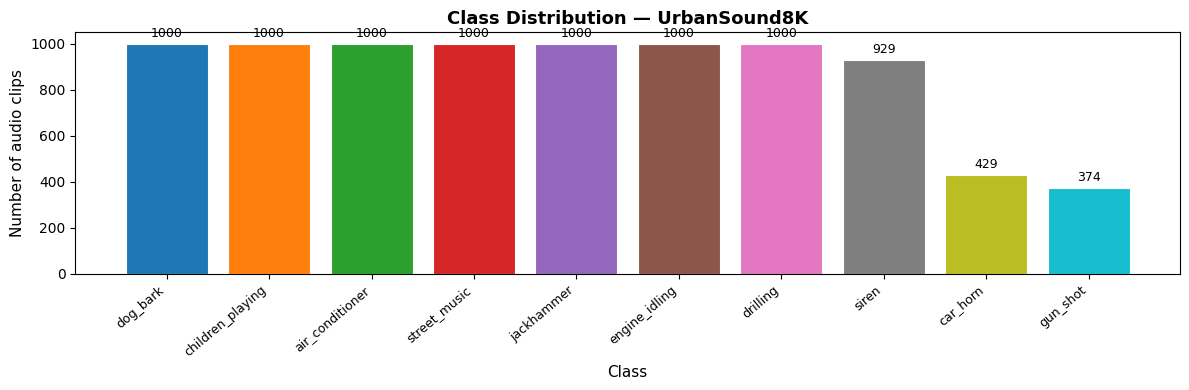

Saved → class_distribution.png


In [8]:
# ── 4c · Class distribution (bar chart) ──────────────────────────────────────
class_counts = meta['class'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=plt.cm.tab10(np.linspace(0, 1, len(class_counts))),
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Number of audio clips', fontsize=11)
ax.set_title('Class Distribution — UrbanSound8K', fontsize=13, fontweight='bold')
ax.set_xticklabels(class_counts.index, rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → class_distribution.png")


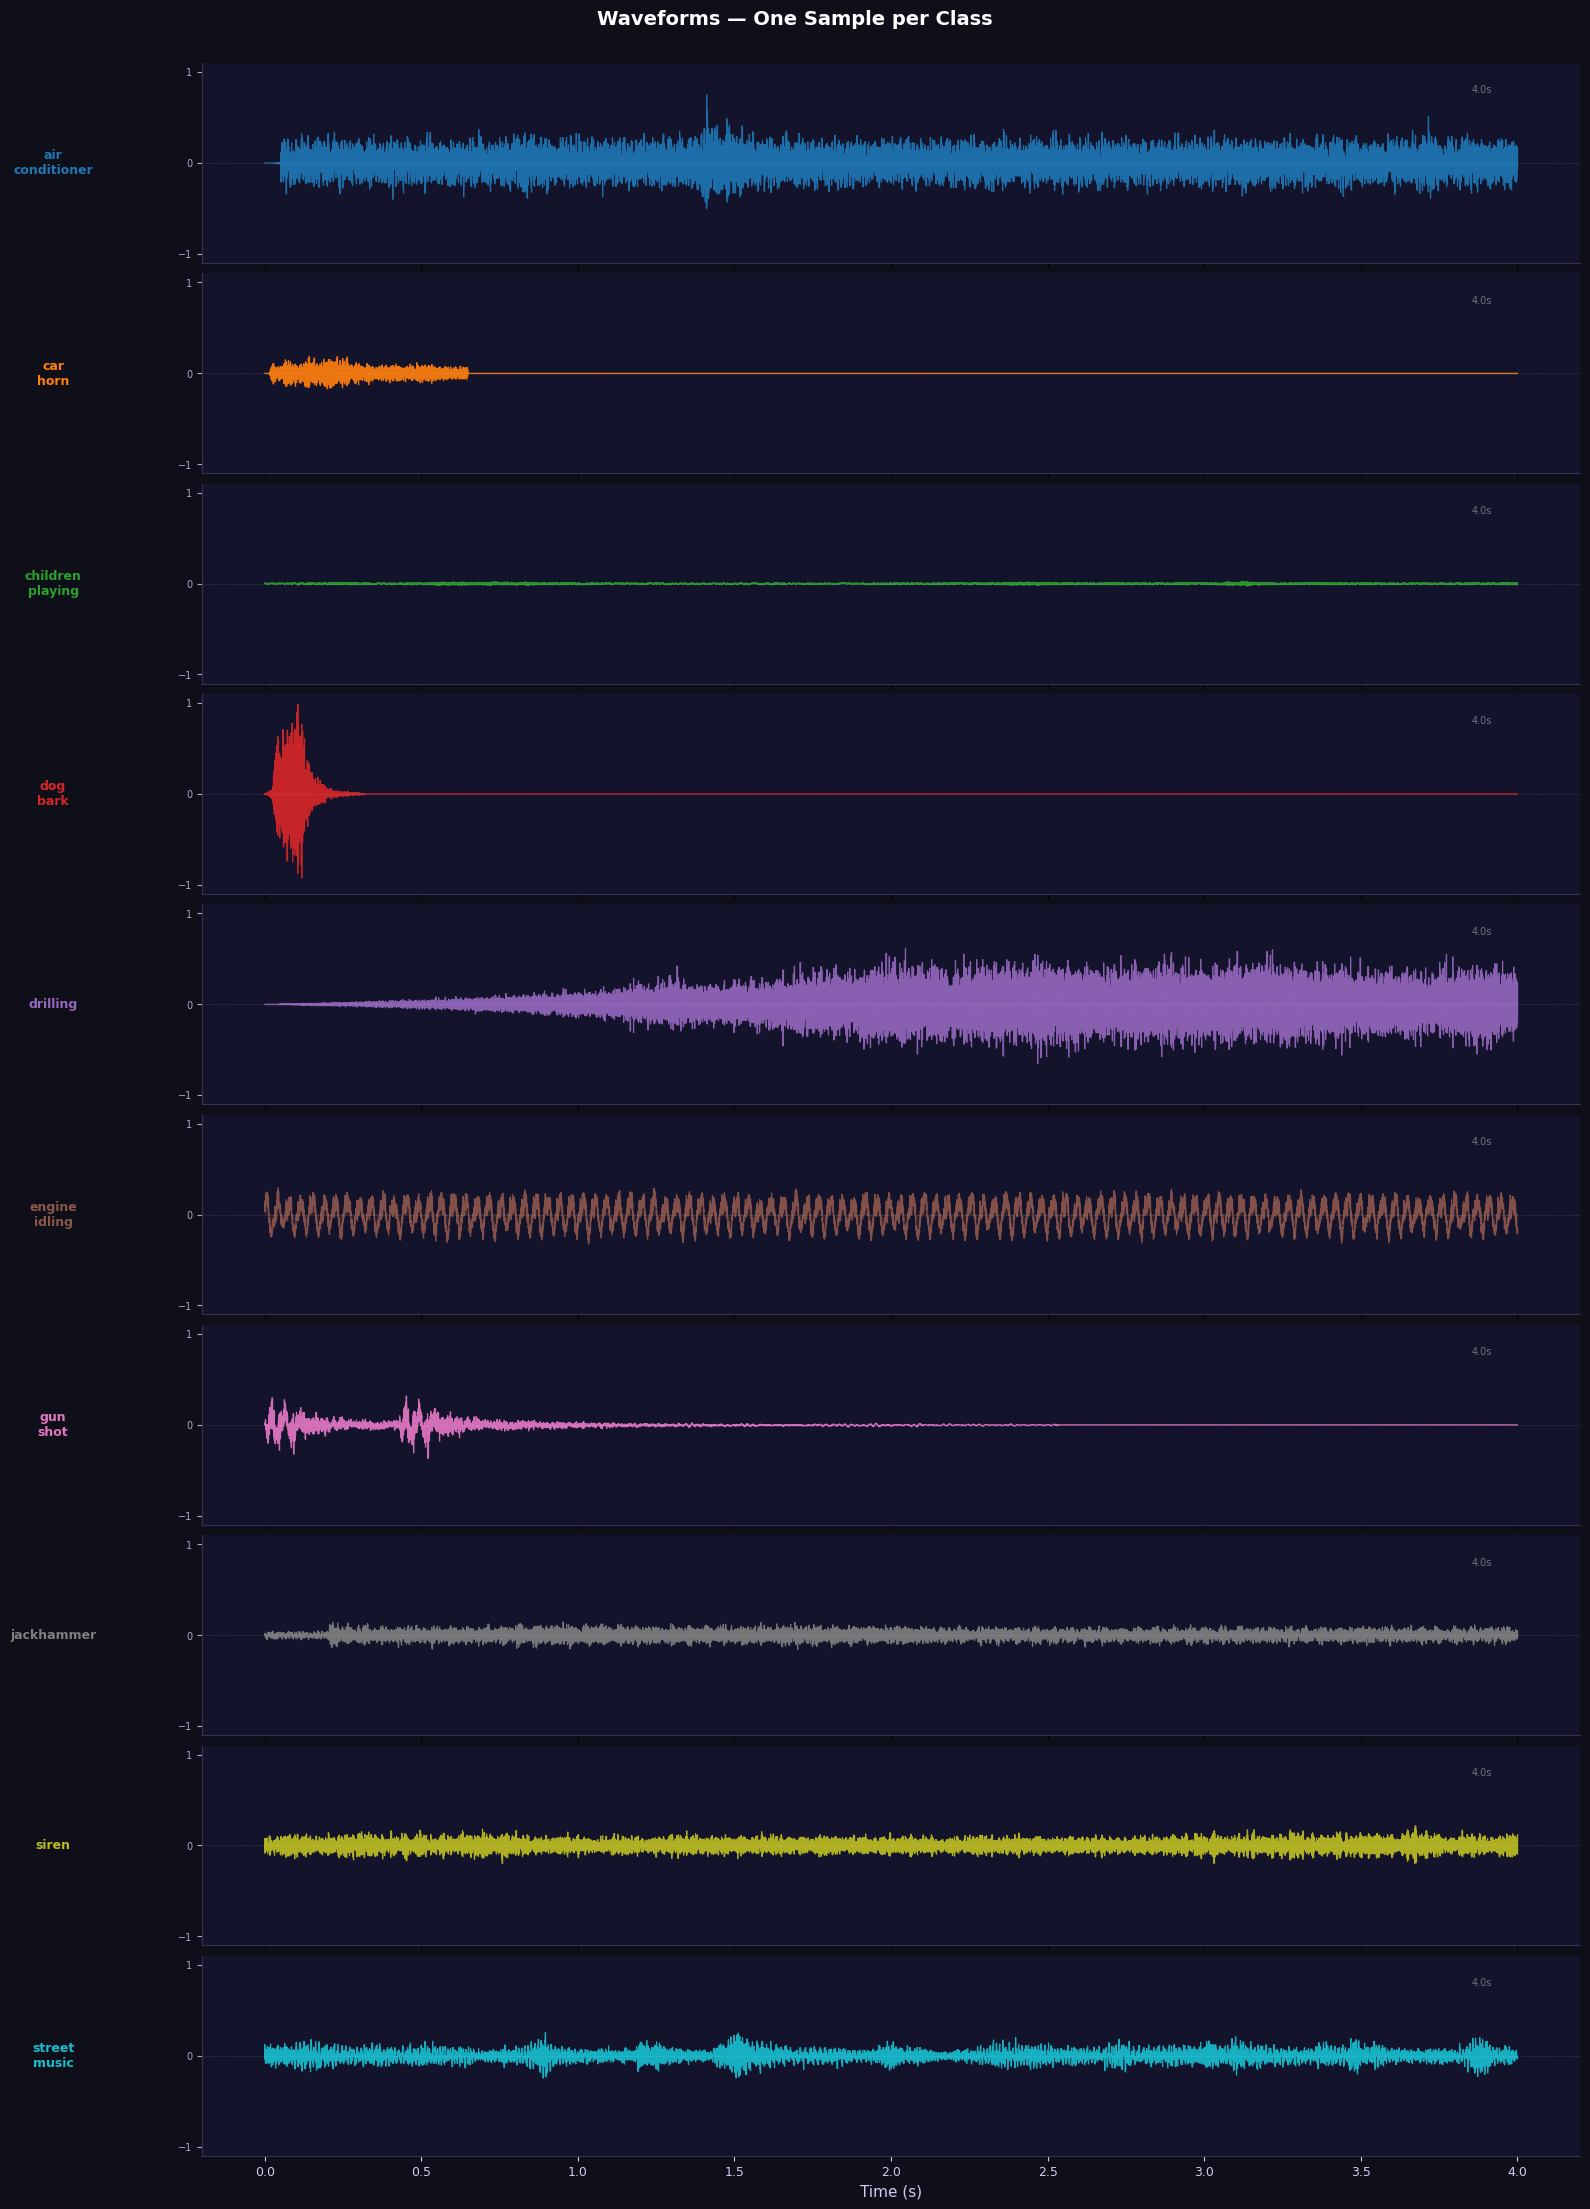

Saved → waveforms_gallery.png


In [9]:
# ── 4d · Waveform gallery (one sample per class) ─────────────────────────────
# Each class occupies its own full-width row for easy comparison.

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(
    NUM_CLASSES, 1,
    figsize=(16, NUM_CLASSES * 2.2),
    sharex=True
)
fig.patch.set_facecolor('#0f0f1a')

for idx, cls in enumerate(CLASS_NAMES):
    row_  = meta[meta['class'] == cls].iloc[0]
    fp    = AUDIO_DIR / f"fold{row_['fold']}" / row_['slice_file_name']
    y     = load_audio(fp)
    t     = np.linspace(0, DURATION, len(y))
    ax    = axes[idx]

    ax.set_facecolor('#13132b')
    ax.plot(t, y, color=colors[idx], linewidth=0.8, alpha=0.9)

    # Subtle fill under the waveform
    ax.fill_between(t, y, alpha=0.18, color=colors[idx])

    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='y', labelsize=7, colors='#aaaacc')
    ax.axhline(0, color='#ffffff22', linewidth=0.5, linestyle='--')

    # Class label box on the left
    ax.set_ylabel(cls.replace('_', '\n'), fontsize=9, rotation=0,
                  labelpad=90, va='center', color=colors[idx],
                  fontweight='bold')

    # Remove top/right spines; style remaining ones
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#333355')
    ax.spines['left'].set_color('#333355')

    # Clip info annotation (duration)
    dur_actual = len(y) / SR
    ax.annotate(f"{dur_actual:.1f}s", xy=(DURATION * 0.98, 0.85),
                xycoords=('data', 'axes fraction'),
                fontsize=7, color='#ffffff66', ha='right')

axes[-1].set_xlabel('Time (s)', fontsize=11, color='#ccccee')
axes[-1].tick_params(axis='x', labelsize=9, colors='#ccccee')

fig.suptitle('Waveforms — One Sample per Class',
             fontsize=14, fontweight='bold', color='white', y=1.002)
plt.tight_layout(h_pad=0.4)
plt.savefig(OUTPUT_DIR / 'waveforms_gallery.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → waveforms_gallery.png")


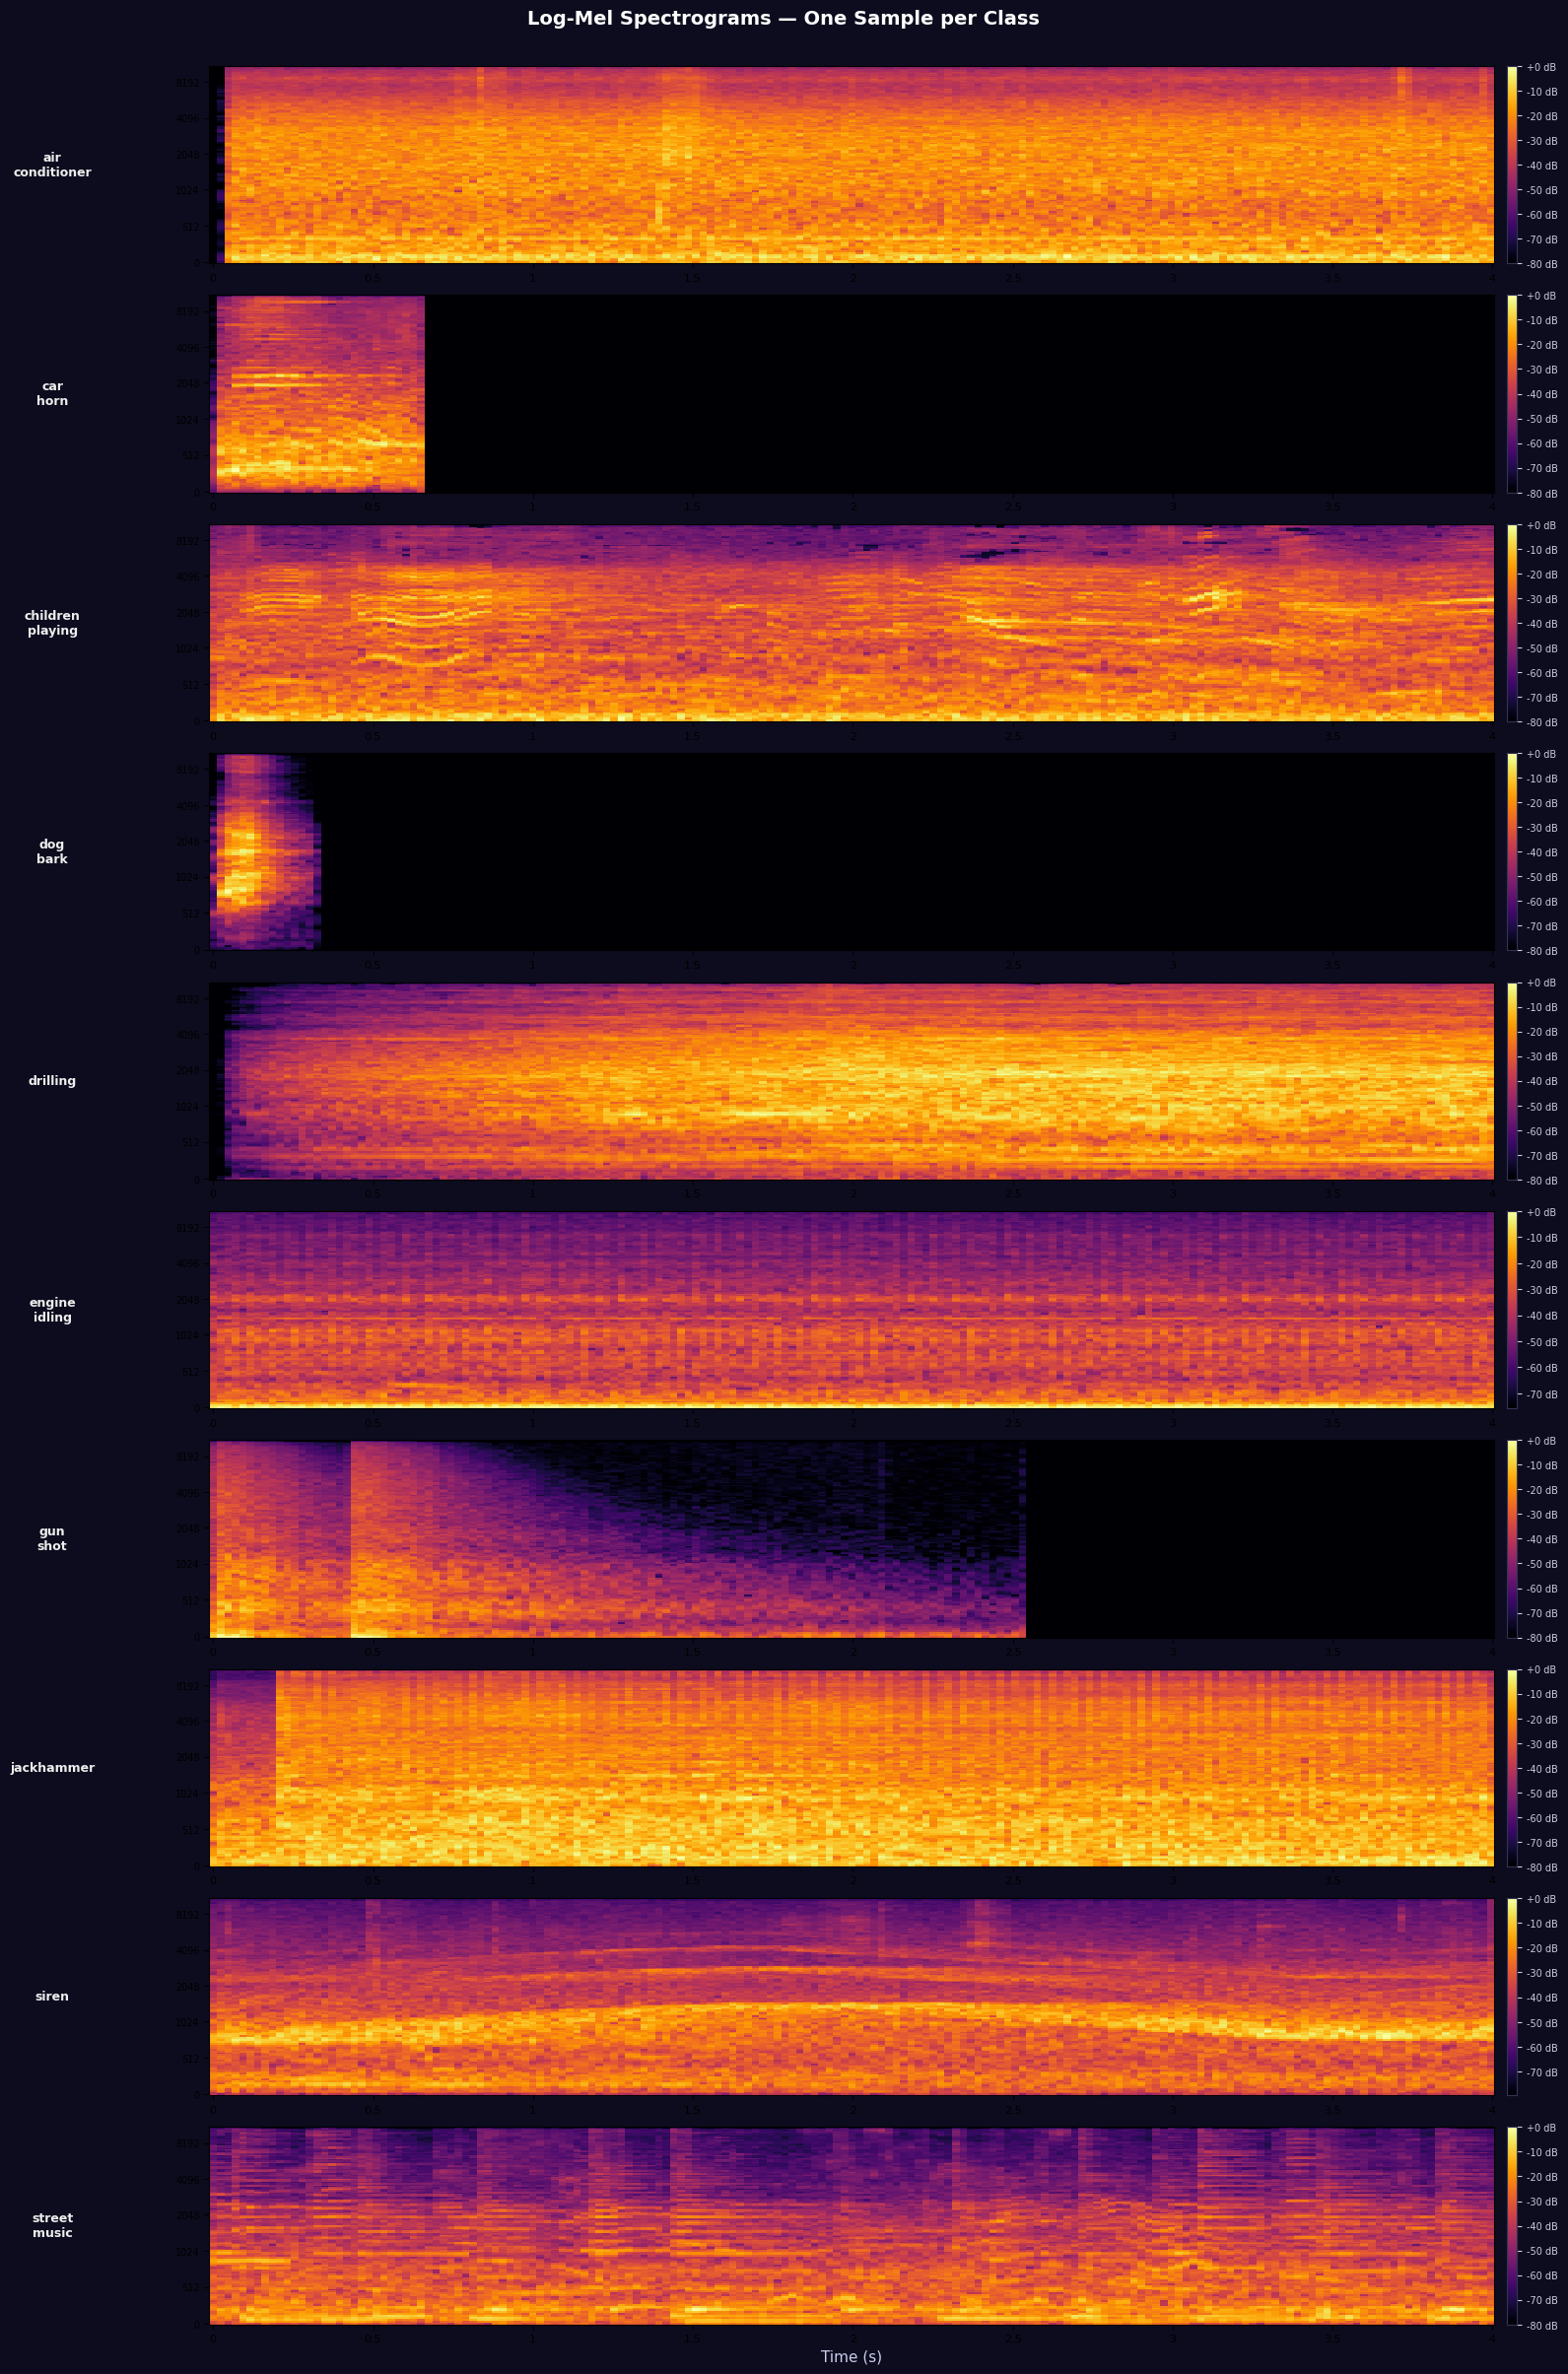

Saved → mel_spectrogram_gallery.png


In [10]:
# ── 4e · Mel-spectrogram gallery (one sample per class) ──────────────────────
# One class per row — wide layout for easy visual inspection.

fig, axes = plt.subplots(
    NUM_CLASSES, 1,
    figsize=(16, NUM_CLASSES * 2.4)
)
fig.patch.set_facecolor('#0c0c1e')

for idx, cls in enumerate(CLASS_NAMES):
    row_ = meta[meta['class'] == cls].iloc[0]
    fp   = AUDIO_DIR / f"fold{row_['fold']}" / row_['slice_file_name']
    y    = load_audio(fp)
    S    = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                           n_fft=N_FFT, hop_length=HOP_LENGTH)
    Sdb  = librosa.power_to_db(S, ref=np.max)
    ax   = axes[idx]

    img  = librosa.display.specshow(
        Sdb, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel',
        ax=ax, cmap='inferno'
    )
    cbar = fig.colorbar(img, ax=ax, format='%+2.0f dB',
                        pad=0.01, fraction=0.012)
    cbar.ax.tick_params(labelsize=7, colors='#ccccdd')
    cbar.outline.set_edgecolor('#333355')

    ax.set_ylabel(cls.replace('_', '\n'), fontsize=9, rotation=0,
                  labelpad=90, va='center', color='#eeeeee', fontweight='bold')
    ax.yaxis.set_tick_params(labelsize=7)
    ax.xaxis.set_tick_params(labelsize=8)

    if idx < NUM_CLASSES - 1:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Time (s)', fontsize=11, color='#ccccee')

fig.suptitle('Log-Mel Spectrograms — One Sample per Class',
             fontsize=14, fontweight='bold', color='white', y=1.002)
plt.tight_layout(h_pad=0.6)
plt.savefig(OUTPUT_DIR / 'mel_spectrogram_gallery.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → mel_spectrogram_gallery.png")


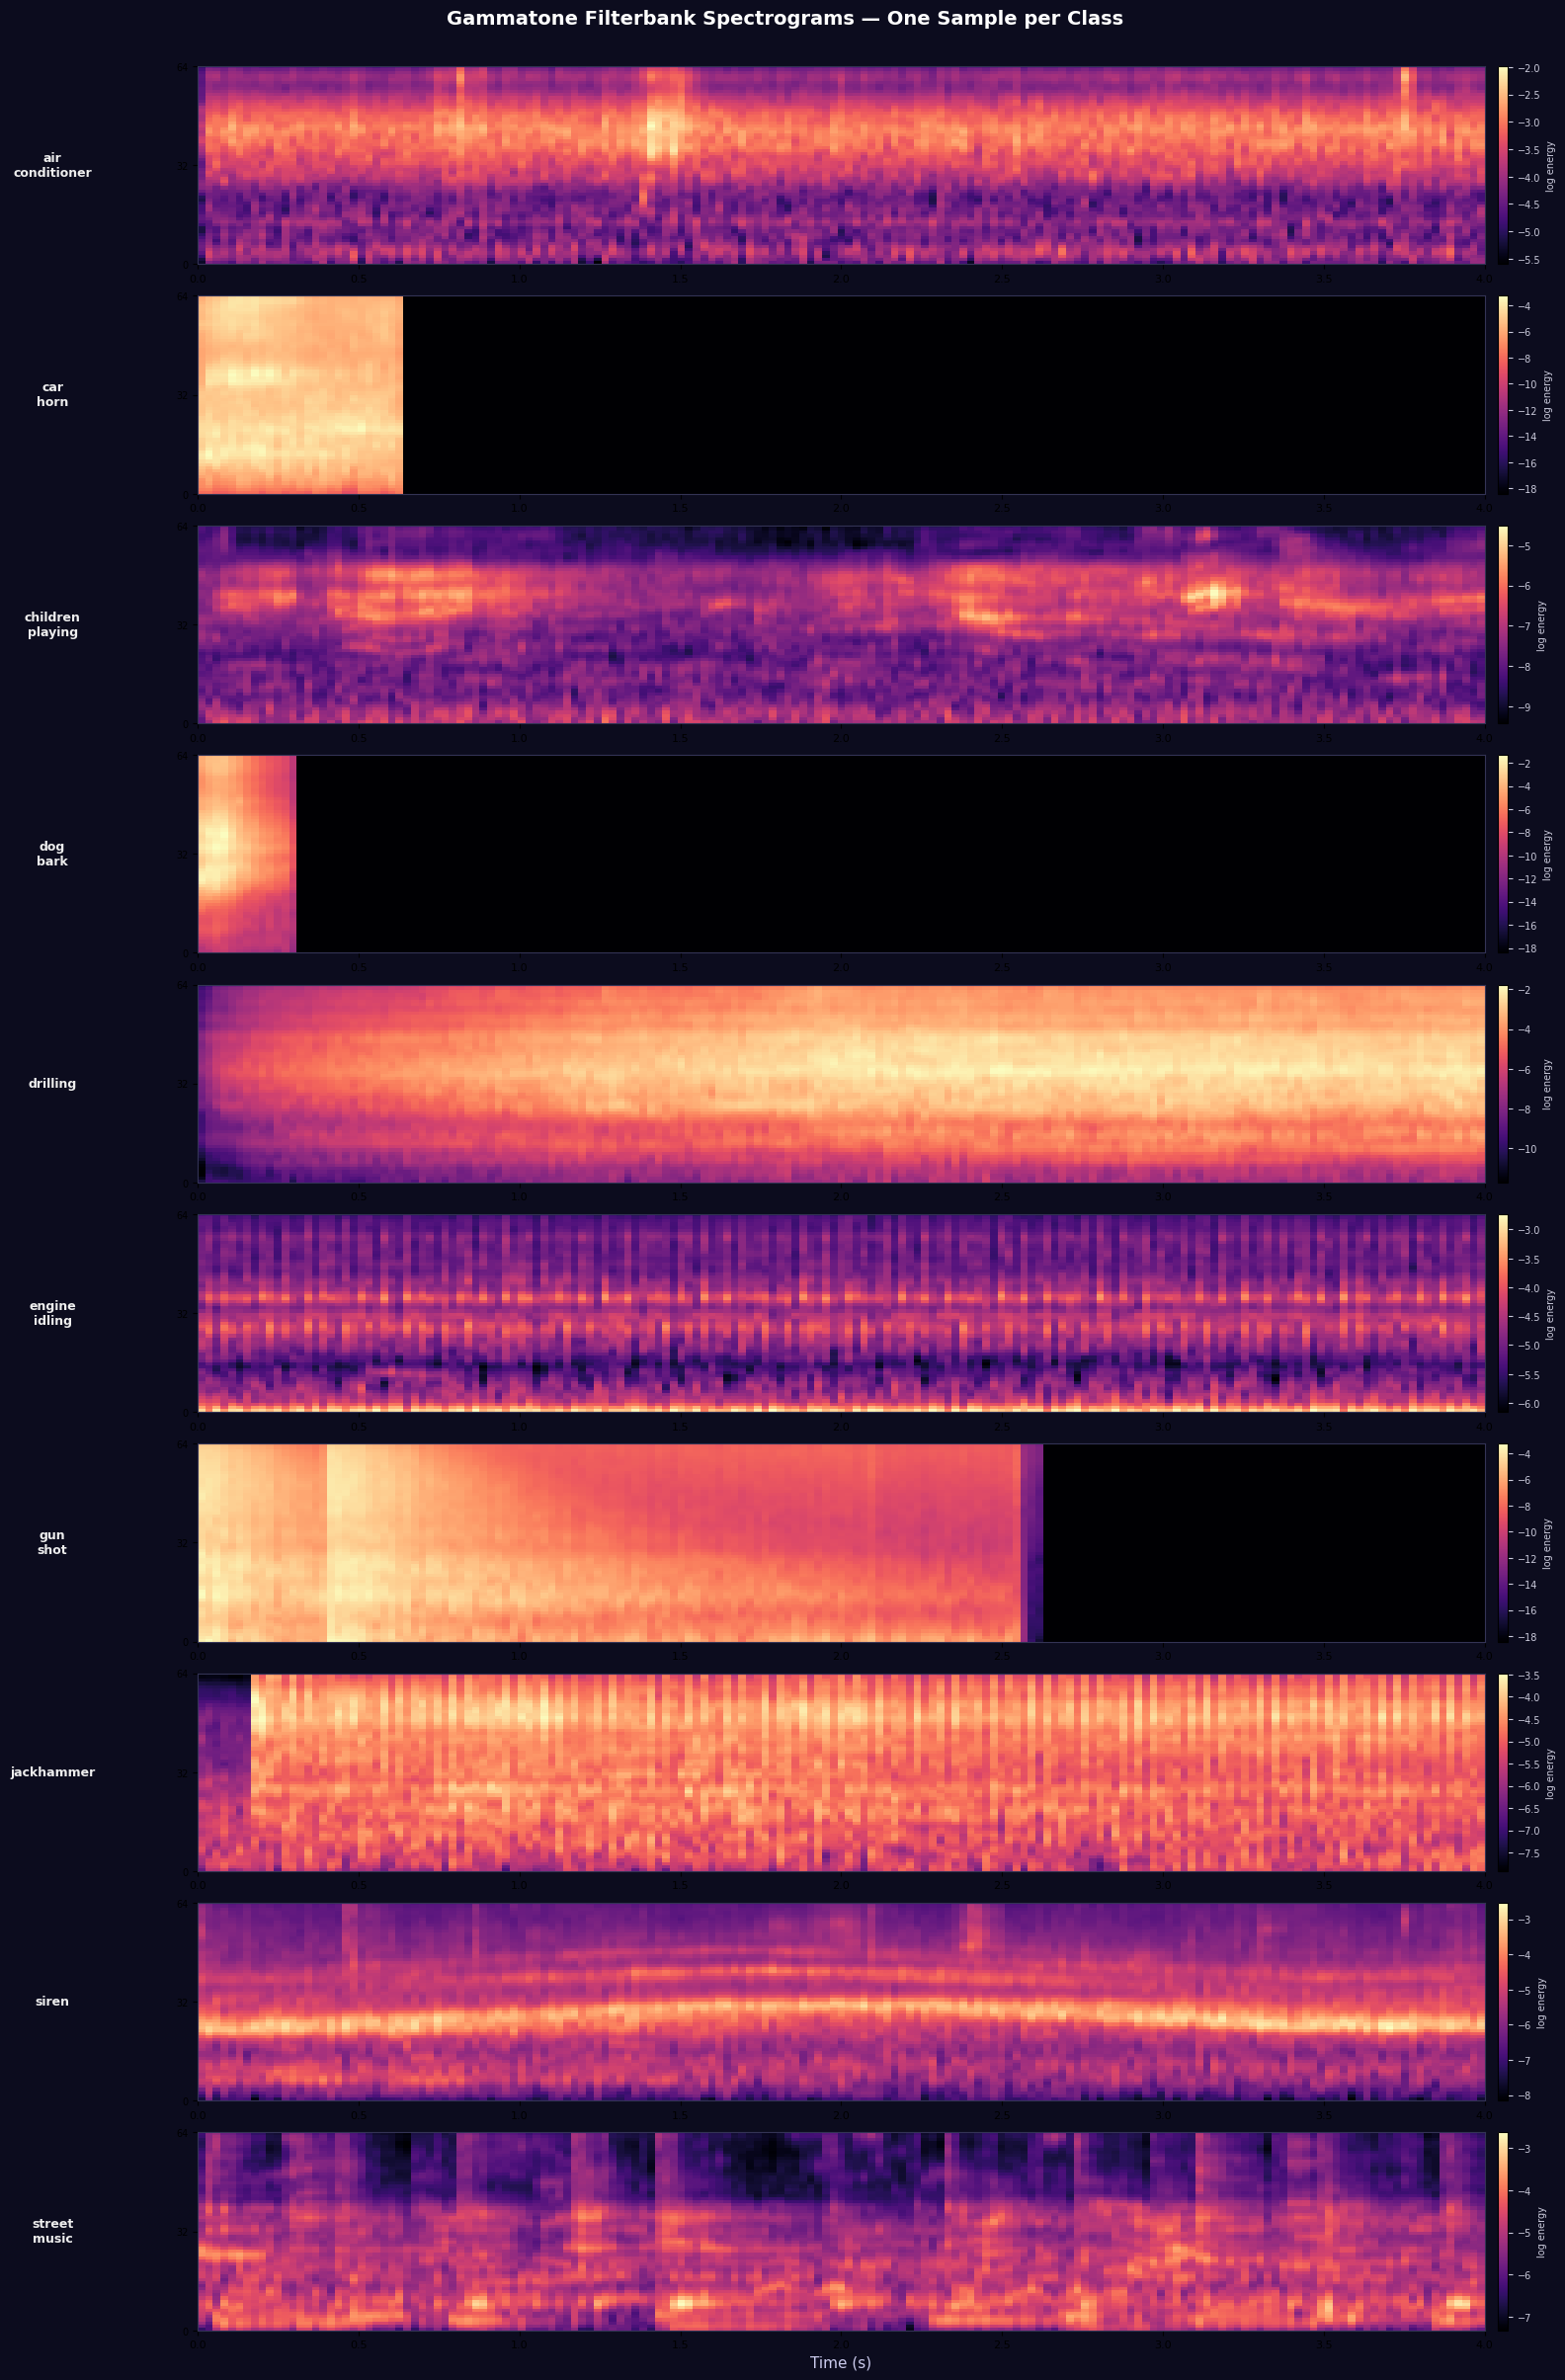

Saved → gammatone_gallery.png


In [11]:
# ── 4f · Gammatone Filterbank spectrogram gallery ────────────────────────────
# ERB-spaced auditory filterbank. One class per row.
# Note: finer low-frequency resolution vs Mel spectrograms above.

fig, axes = plt.subplots(
    NUM_CLASSES, 1,
    figsize=(16, NUM_CLASSES * 2.4)
)
fig.patch.set_facecolor('#0c0c1e')

for idx, cls in enumerate(CLASS_NAMES):
    row_ = meta[meta['class'] == cls].iloc[0]
    fp   = AUDIO_DIR / f"fold{row_['fold']}" / row_['slice_file_name']
    y    = load_audio(fp)
    ax   = axes[idx]

    gt_spec = _gtfw.fft_gtgram(
        y.astype(np.float64), SR,
        N_FFT / SR, HOP_LENGTH / SR,
        N_GTFB, 50.0
    )
    gt_log = np.log(gt_spec + 1e-8)

    im = ax.imshow(
        gt_log, aspect='auto', origin='lower',
        cmap='magma',
        extent=[0, DURATION, 0, N_GTFB]
    )
    cbar = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.012)
    cbar.ax.tick_params(labelsize=7, colors='#ccccdd')
    cbar.set_label('log energy', fontsize=7, color='#ccccdd')

    ax.set_ylabel(cls.replace('_', '\n'), fontsize=9, rotation=0,
                  labelpad=90, va='center', color='#eeeeee', fontweight='bold')
    ax.set_yticks([0, N_GTFB // 2, N_GTFB])
    ax.set_yticklabels(['0', f'{N_GTFB//2}', f'{N_GTFB}'], fontsize=7)
    ax.tick_params(axis='x', labelsize=8)

    if idx < NUM_CLASSES - 1:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Time (s)', fontsize=11, color='#ccccee')

    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

fig.suptitle('Gammatone Filterbank Spectrograms — One Sample per Class',
             fontsize=14, fontweight='bold', color='white', y=1.002)
plt.tight_layout(h_pad=0.6)
plt.savefig(OUTPUT_DIR / 'gammatone_gallery.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → gammatone_gallery.png")


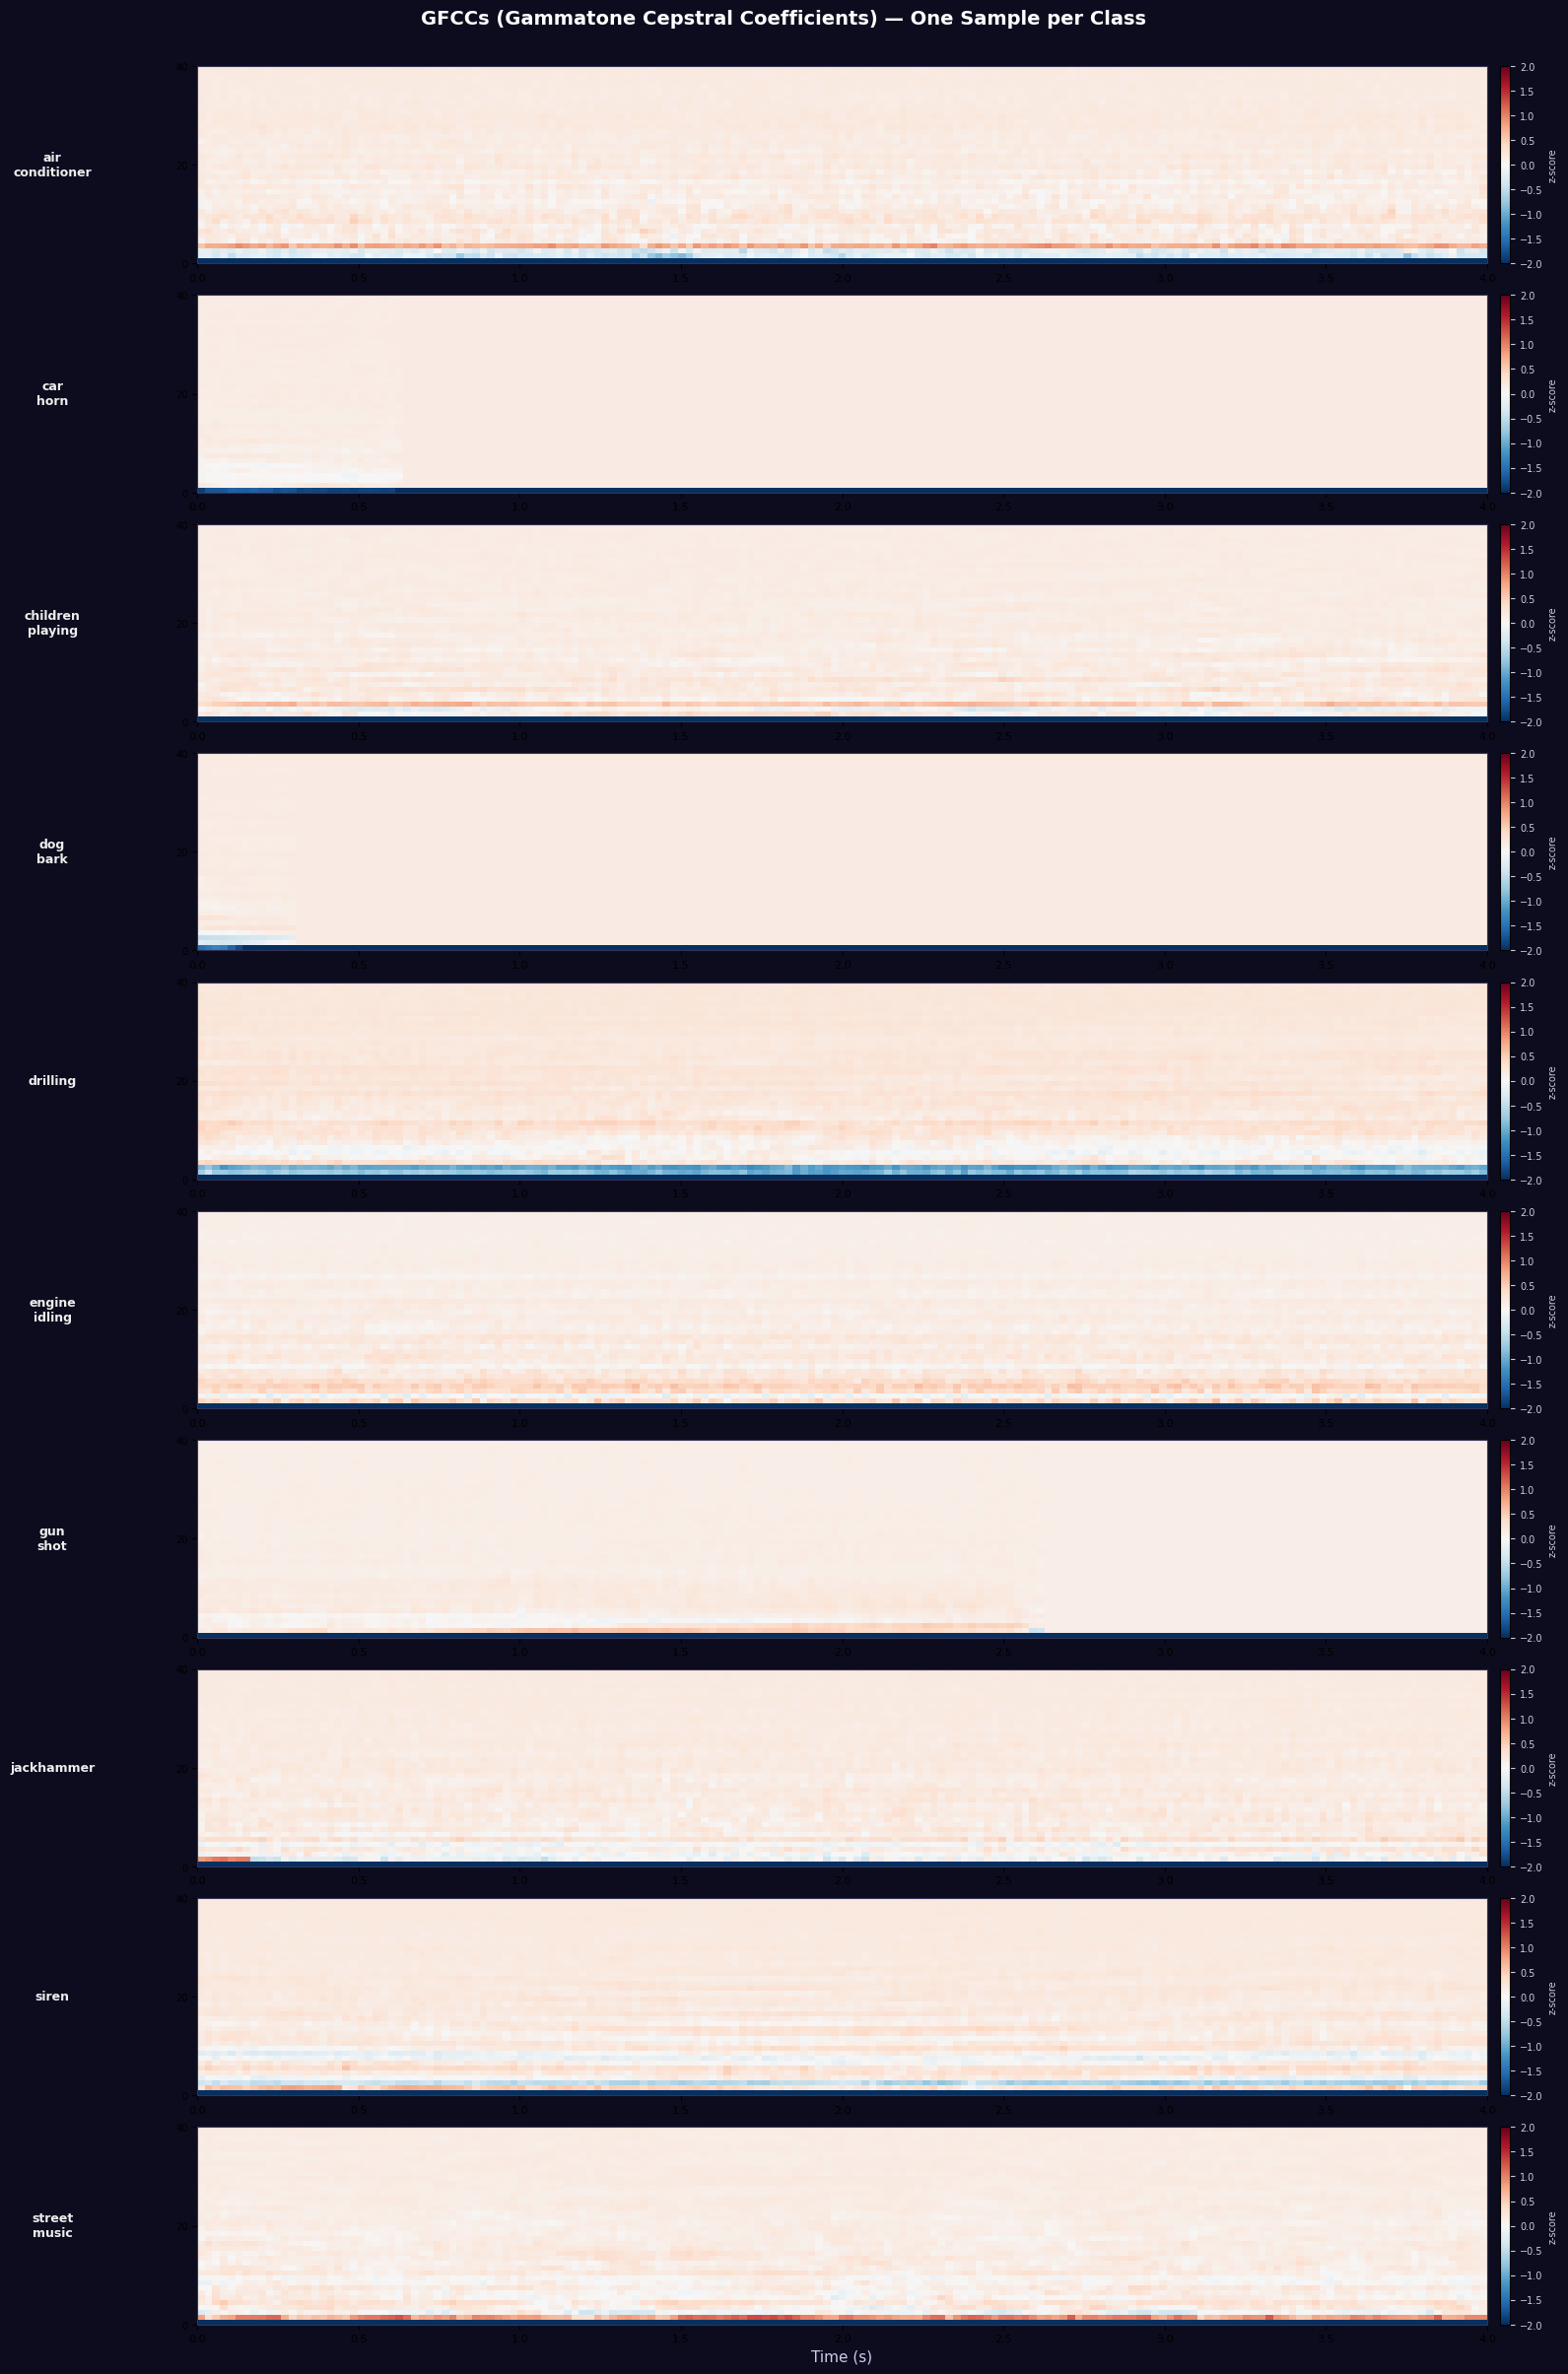

Saved → gfcc_gallery.png


In [12]:
# ── 4g · GFCC gallery (one sample per class) ─────────────────────────────────
# DCT of log-Gammatone energies. One class per row.

fig, axes = plt.subplots(
    NUM_CLASSES, 1,
    figsize=(16, NUM_CLASSES * 2.4)
)
fig.patch.set_facecolor('#0c0c1e')

for idx, cls in enumerate(CLASS_NAMES):
    row_ = meta[meta['class'] == cls].iloc[0]
    fp   = AUDIO_DIR / f"fold{row_['fold']}" / row_['slice_file_name']
    y    = load_audio(fp)
    ax   = axes[idx]

    gt_spec = _gtfw.fft_gtgram(
        y.astype(np.float64), SR,
        N_FFT / SR, HOP_LENGTH / SR,
        N_GTFB, 50.0
    )
    gt_log = np.log(gt_spec + 1e-8)
    gfcc   = _scipy_dct(gt_log, type=2, axis=0, norm='ortho')[:N_GFCC, :]

    mu  = gfcc.mean()
    std = gfcc.std() + 1e-8
    gfcc_norm = np.clip((gfcc - mu) / std, -2.0, 2.0)
    
    im = ax.imshow(
        gfcc_norm, aspect='auto', origin='lower',
        cmap='RdBu_r',
        extent=[0, DURATION, 0, N_GFCC],
        vmin=-2.0, vmax=2.0
    )
    cbar = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.012)
    cbar.ax.tick_params(labelsize=7, colors='#ccccdd')
    cbar.set_label('z-score', fontsize=7, color='#ccccdd')

    ax.set_ylabel(cls.replace('_', '\n'), fontsize=9, rotation=0,
                  labelpad=90, va='center', color='#eeeeee', fontweight='bold')
    ax.set_yticks([0, N_GFCC // 2, N_GFCC])
    ax.set_yticklabels(['0', f'{N_GFCC//2}', f'{N_GFCC}'], fontsize=7)
    ax.tick_params(axis='x', labelsize=8)

    if idx < NUM_CLASSES - 1:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Time (s)', fontsize=11, color='#ccccee')

    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

fig.suptitle('GFCCs (Gammatone Cepstral Coefficients) — One Sample per Class',
             fontsize=14, fontweight='bold', color='white', y=1.002)
plt.tight_layout(h_pad=0.6)
plt.savefig(OUTPUT_DIR / 'gfcc_gallery.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → gfcc_gallery.png")


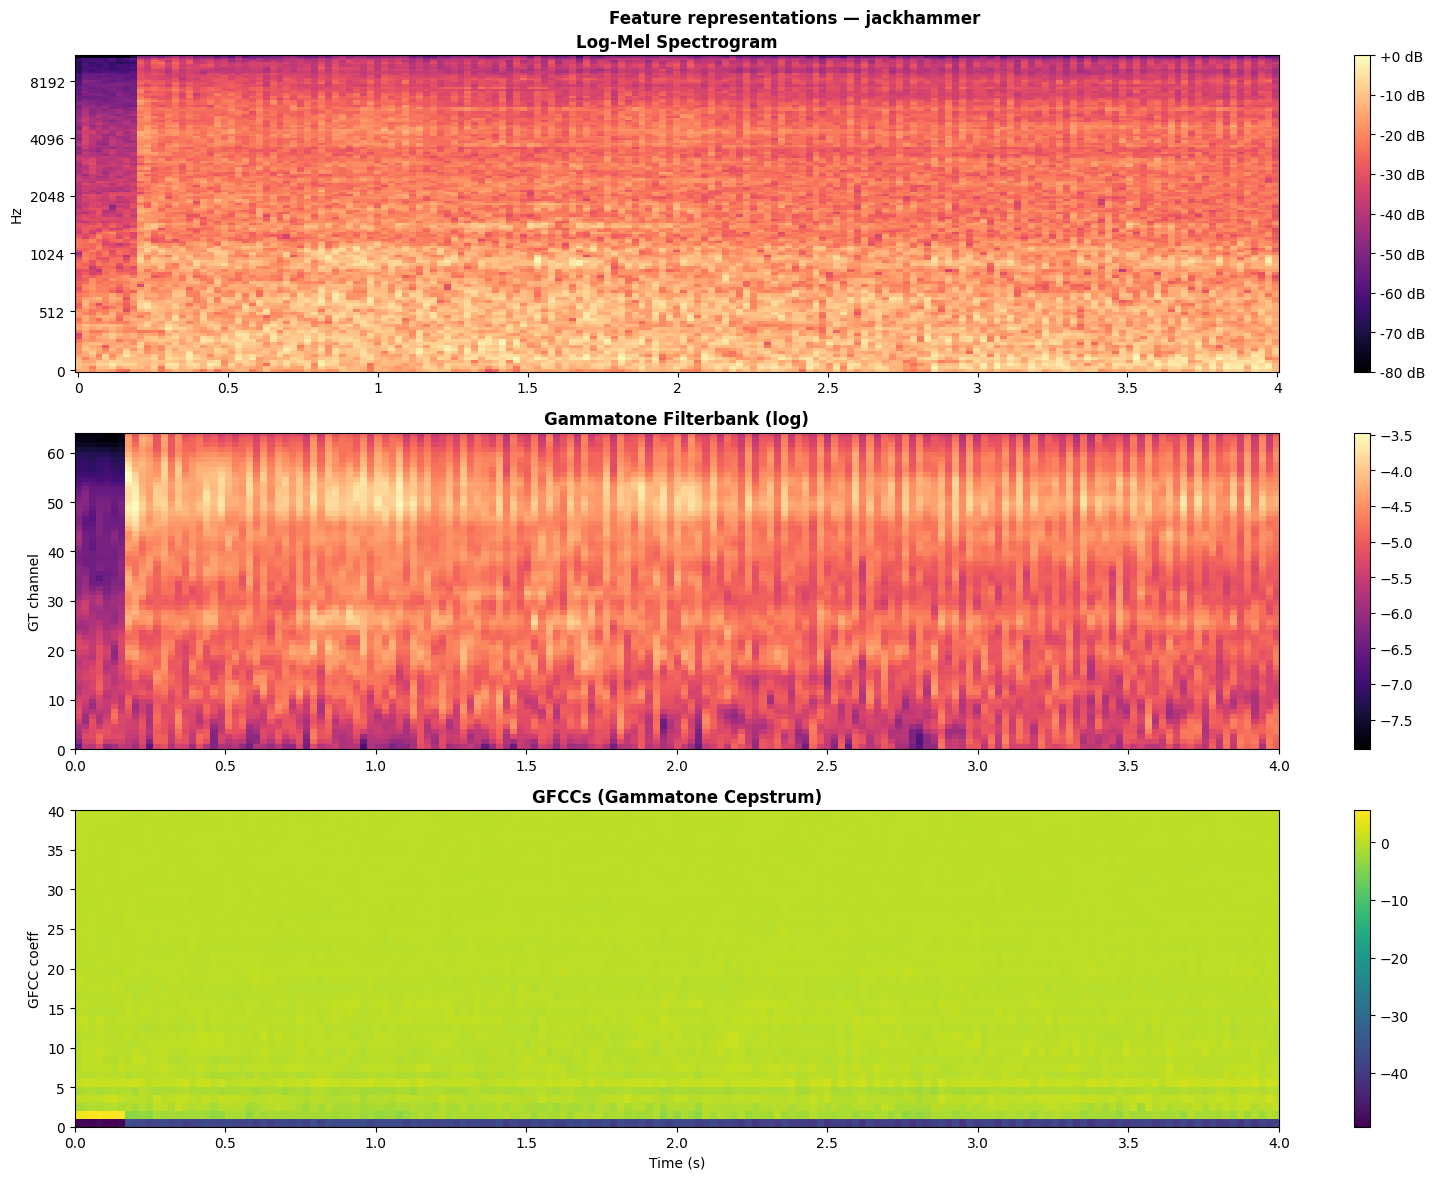

Saved → feature_comparison.png


In [13]:
# ── 4h · Feature comparison for a single clip ────────────────────────────────
# Side-by-side view of Mel, Gammatone, and GFCC for the same clip,
# to illustrate how each representation captures different aspects.

row = meta[meta['class'] == 'jackhammer'].iloc[0]
fp  = AUDIO_DIR / f"fold{row['fold']}" / row['slice_file_name']
y   = load_audio(fp)

mel   = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH)
mel_db = librosa.power_to_db(mel, ref=np.max)

gt_spec = _gtfw.fft_gtgram(y.astype(np.float64), SR,
                             N_FFT/SR, HOP_LENGTH/SR, N_GTFB, 50.0)
gt_log  = np.log(gt_spec + 1e-8)
gfcc    = _scipy_dct(gt_log, type=2, axis=0, norm='ortho')[:N_GFCC, :]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

img0 = librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set_title('Log-Mel Spectrogram', fontweight='bold')
fig.colorbar(img0, ax=axes[0], format='%+2.0f dB')

img1 = axes[1].imshow(gt_log, aspect='auto', origin='lower', cmap='magma',
                       extent=[0, DURATION, 0, N_GTFB])
axes[1].set_title('Gammatone Filterbank (log)', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('GT channel')
fig.colorbar(img1, ax=axes[1])

img2 = axes[2].imshow(gfcc, aspect='auto', origin='lower', cmap='viridis',
                       extent=[0, DURATION, 0, N_GFCC])
axes[2].set_title('GFCCs (Gammatone Cepstrum)', fontweight='bold')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('GFCC coeff')
fig.colorbar(img2, ax=axes[2])

fig.suptitle('Feature representations — jackhammer', fontsize=12,
             fontweight='bold')
axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → feature_comparison.png")


```
# ── 4i · Audio Playback — Listen to One Sample per Class ───────────────────
```

### 4.2 Audio Playback — Listen to One Sample per Class

Hearing the sounds is just as important as seeing their spectrograms.  
Each urban-sound class has a distinct **acoustic texture** that may not be fully
captured by a 2-D plot:

| Class | What to listen for |
|---|---|
| `air_conditioner` | Steady, broadband white-noise hum with little temporal variation |
| `car_horn` | Short, loud, tonal bursts — typically 0.5–2 s |
| `children_playing` | Voices, laughter, chaotic mixing — high temporal variability |
| `dog_bark` | Impulsive, rhythmic barks with silent gaps in between |
| `drilling` | High-frequency, rhythmic mechanical noise with a strong fundamental |
| `engine_idling` | Low-frequency periodic hum, quasi-stationary like A/C but lower pitch |
| `gun_shot` | Single, extremely impulsive transient — most energy in the first 50 ms |
| `jackhammer` | Rhythmic percussive impacts, similar to drilling but louder and slower |
| `siren` | Frequency-modulated tonal sweep (rising and falling pitch) |
| `street_music` | Complex harmonic mixture — instruments + voices + ambient noise |

> **Why this matters for feature design:**  
> After listening you will notice that some pairs are acoustically close
> (e.g. *air_conditioner* vs *engine_idling*, *drilling* vs *jackhammer*).  
> These are precisely the classes where delta-MFCCs, GFCCs, and multi-scale
> Mel features add the most discriminative power.  
> The confusion matrix in Section 9 will confirm these are the hardest pairs.

**Note:** `IPython.display.Audio` renders an interactive audio widget directly
inside the Jupyter / Colab notebook cell output.  No extra library is needed —
it is part of the standard IPython package that ships with every Jupyter
installation.

In [14]:
# ── 4i · Audio Playback — Listen to One Sample per Class ─────────────────────
# IPython.display.Audio renders an interactive audio widget in Jupyter / Colab.
# Clicking the ▶ button plays the raw waveform at the dataset sample rate.

from IPython.display import display, Audio
import ipywidgets as widgets

print("=" * 60)
print(" Audio Playback — One Sample per Class")
print("=" * 60)
print("Click ▶ on any player below to listen.\n")

for cls in CLASS_NAMES:
    # Pick the first available clip for this class
    row = meta[meta['class'] == cls].iloc[0]
    fp  = AUDIO_DIR / f"fold{row['fold']}" / row['slice_file_name']

    # Load at the original sample rate (no resampling) for highest fidelity
    y_play, sr_play = librosa.load(str(fp), sr=None, mono=True)

    # Display a label and the audio widget
    label_widget = widgets.HTML(
        value=(
            f'<b style="font-size:13px; color:#2c3e50;">{cls}</b>'
            f'<span style="color:#7f8c8d; font-size:11px;">'
            f'  — fold {row["fold"]} · {row["slice_file_name"]}'
            f'  · {len(y_play)/sr_play:.2f} s · {sr_play} Hz</span>'
        )
    )
    display(label_widget)
    display(Audio(data=y_play, rate=sr_play, autoplay=False))
    print()   # blank line for spacing

 Audio Playback — One Sample per Class
Click ▶ on any player below to listen.



HTML(value='<b style="font-size:13px; color:#2c3e50;">air_conditioner</b><span style="color:#7f8c8d; font-size…

HTML(value='<b style="font-size:13px; color:#2c3e50;">car_horn</b><span style="color:#7f8c8d; font-size:11px;"…

HTML(value='<b style="font-size:13px; color:#2c3e50;">children_playing</b><span style="color:#7f8c8d; font-siz…

HTML(value='<b style="font-size:13px; color:#2c3e50;">dog_bark</b><span style="color:#7f8c8d; font-size:11px;"…

...

HTML(value='<b style="font-size:13px; color:#2c3e50;">engine_idling</b><span style="color:#7f8c8d; font-size:1…

HTML(value='<b style="font-size:13px; color:#2c3e50;">gun_shot</b><span style="color:#7f8c8d; font-size:11px;"…

HTML(value='<b style="font-size:13px; color:#2c3e50;">jackhammer</b><span style="color:#7f8c8d; font-size:11px…

HTML(value='<b style="font-size:13px; color:#2c3e50;">siren</b><span style="color:#7f8c8d; font-size:11px;">  …

HTML(value='<b style="font-size:13px; color:#2c3e50;">street_music</b><span style="color:#7f8c8d; font-size:11…

---
## 5 · Feature Extraction, Normalisation & Caching

### 5.1 Explanation — Feature Design Rationale

We extract a **565-dimensional** feature vector per time frame, compared to the 123-dim baseline.  
The table below summarises every group and explains why it was included.

| Feature | Dim | Motivation |
|---|---|---|
| Log-Mel spectrogram (128 bins) | 128 | Perceptually-weighted time-frequency energy; the standard representation for audio classification |
| MFCCs (40 coeffs) | 40 | Compact spectral envelope description; widely used as a speech/sound descriptor |
| Δ-MFCCs | 40 | **Rate of spectral change** — discriminates impulsive (car-horn onset) vs. sustained (engine-idle) sounds |
| ΔΔ-MFCCs | 40 | **Spectral acceleration** — captures onset/offset curvature; helps with transient sounds |
| RMS Energy | 1 | Global loudness dynamics |
| Chroma STFT | 12 | Pitch-class content — helpful for musical sounds (street music, children playing) |
| Spectral Contrast | 6 | Peak-vs-valley energy in 6 sub-bands; captures harmonic vs. noise-like structure |
| Zero-Crossing Rate | 1 | Noisiness indicator — distinguishes voiced/tonal from percussive sounds |
| Spectral Rolloff | 1 | Frequency below which 85 % of energy is contained |
| **GFCCs — Gammatone Filterbank Cepstral Coefficients** | **40** | Described in detail below ↓ |
| **Multi-scale Mel (short hop = 256)** | **128** | Described in detail below ↓ |
| **Multi-scale Mel (long  hop = 1024)** | **128** | Described in detail below ↓ |
| **Total** | **565** | |

---

#### Why GFCCs (Gammatone Filterbank Cepstral Coefficients)?

The standard Mel filterbank places triangular filters on the **Mel scale** — a rough psychoacoustic approximation.  
The **Gammatone filterbank** models the human **basilar membrane** response using the **ERB (Equivalent Rectangular Bandwidth)** scale with gammatone-shaped impulse responses.  
GFCCs are computed by:
```
1. Compute gammatone power spectrogram  →  (N_GTFB=64, T)
2. Apply log compression                 →  log(S + ε)
3. Apply DCT-II across frequency axis    →  keep first 40 coefficients
```
**Why they help here:**
- At low frequencies (<1 kHz) the ERB scale is finer than Mel — it allocates more channels to the region where engine noise, air conditioner hum, and dog-bark fundamentals live.
- For urban sounds, perceptual frequency-resolution differences matter for textures like *engine_idling* vs. *street_music* that differ mainly in low-frequency tonal structure.
- GFCCs have demonstrated improved accuracy over MFCCs alone on environmental sound datasets (Valero & Alias, 2012; Eronen et al., 2006).

---

#### Why Multi-scale Log-Mel (multiple hop lengths)?

A single hop length (512 ≈ 23 ms/frame) gives **one temporal resolution**.  

| Scale | Hop (samples) | Frame rate | Good at |
|---|---|---|---|
| Short | 256 | ~86 fps (11.6 ms) | Transients: gun-shot (≈20 ms burst), car-horn onset |
| Standard | 512 | ~43 fps (23.2 ms) | General-purpose |
| Long | 1024 | ~22 fps (46.4 ms) | Sustained textures: A/C hum, engine-idle |

Concatenating all three scales lets the **same GRU** jointly attend to fine and coarse temporal structure without changing the architecture — it simply sees more context per frame.

---

#### Normalisation strategy

Per-sample z-score (baseline approach) normalises each clip independently, discarding inter-clip scale information.  
**Global normalisation** pre-computes the mean (μ) and standard deviation (σ) across **all training frames** using Welford's online algorithm (numerically stable), then applies:

```
x_norm = (x − μ) / (σ + ε)
```

This makes the model's input distribution consistent across splits and prevents data leakage (statistics are computed only on training folds).

---

#### Caching

Feature extraction for 8 732 clips takes several minutes.  
We save each clip's feature matrix as a `.npy` file (`CACHE_DIR/<fold>_<filename>.npy`) so that every subsequent run skips extraction and loads directly from disk — reducing DataLoader overhead from ~4 s/clip to ~0.01 s/clip.


In [15]:
# ── 5a · Feature extraction function ─────────────────────────────────────────
def extract_features(y, sr=SR):
    """
    Extract 565-dim acoustic features per frame.
    Returns ndarray of shape (T, 565).
    """
    # 1. Standard Log-Mel  (128 × T)
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs  (40 × T)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)

    # 3. Δ-MFCCs  (40 × T)
    d_mfcc  = librosa.feature.delta(mfcc, order=1)

    # 4. ΔΔ-MFCCs  (40 × T)
    dd_mfcc = librosa.feature.delta(mfcc, order=2)

    # 5. RMS Energy  (1 × T)
    rms    = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)

    # 6. Chroma STFT  (12 × T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=N_CHROMA,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)

    # 7. Spectral Contrast  (6 × T)
    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[:N_CONTRAST, :]

    # 8. Zero-Crossing Rate  (1 × T)
    zcr    = librosa.feature.zero_crossing_rate(y=y, frame_length=N_FFT,
                                                 hop_length=HOP_LENGTH)

    # 9. Spectral Rolloff  (1 × T)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=N_FFT,
                                                hop_length=HOP_LENGTH,
                                                roll_percent=0.85)

    # 10. GFCCs from Gammatone filterbank  (40 × T) — NEW
    _gt   = _gtfw.fft_gtgram(y.astype(np.float64), sr,
                               N_FFT/sr, HOP_LENGTH/sr, N_GTFB, 50.0)
    _glog = np.log(_gt + 1e-8)
    gfcc  = _scipy_dct(_glog, type=2, axis=0, norm='ortho')[:N_GFCC, :]

    # 11. Multi-scale Mel — short hop 256  (128 × T_short)  — NEW
    _ms    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_SHORT)
    mel_s  = librosa.power_to_db(_ms, ref=np.max)

    # 12. Multi-scale Mel — long hop 1024  (128 × T_long)  — NEW
    _ml    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LONG)
    mel_l  = librosa.power_to_db(_ml, ref=np.max)

    # ── Align all to reference T (from standard hop=512) ────────────────────
    T = mel_db.shape[1]
    def _align(arr):
        if arr.shape[1] > T:  return arr[:, :T]
        if arr.shape[1] < T:  return np.pad(arr, ((0,0),(0,T-arr.shape[1])))
        return arr

    features = np.vstack([
        mel_db, mfcc, d_mfcc, dd_mfcc, rms, chroma, contrast, zcr, rolloff,
        _align(gfcc), _align(mel_s), _align(mel_l)
    ])                              # (565, T)
    return features.T.astype(np.float32)   # (T, 565)


# ── Sanity check ─────────────────────────────────────────────────────────────
_r = meta.iloc[0]
_y = load_audio(AUDIO_DIR / f"fold{_r['fold']}" / _r['slice_file_name'])
_f = extract_features(_y)
print(f"Sample feature shape: {_f.shape}  (expected T × {FEATURE_DIM})")
assert _f.shape[1] == FEATURE_DIM, f"Mismatch: got {_f.shape[1]}"
MAX_LEN = _f.shape[0]
print(f"MAX_LEN = {MAX_LEN} frames ✓")


Sample feature shape: (173, 565)  (expected T × 565)
MAX_LEN = 173 frames ✓


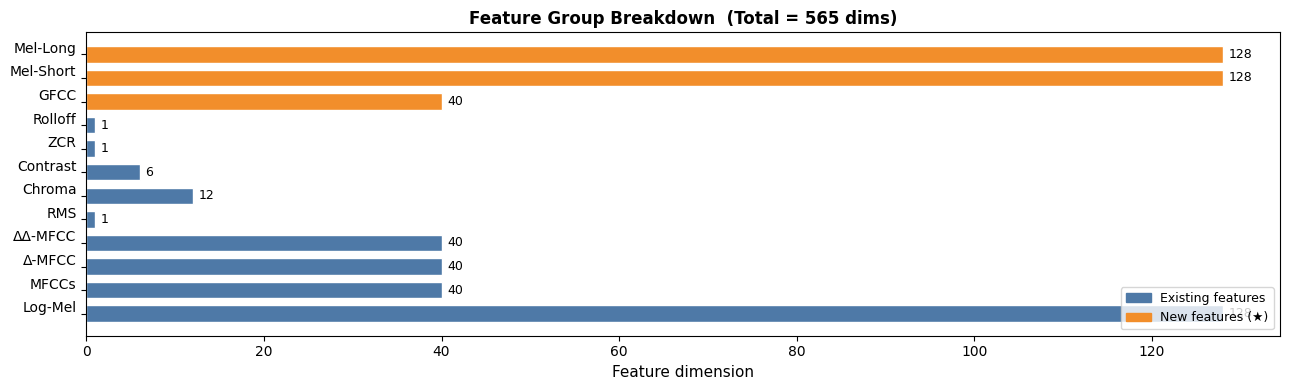

Saved → feature_breakdown.png


In [16]:
# ── 5b · Visualise feature dimensionality breakdown ───────────────────────────
feature_groups = {
    'Log-Mel\n': 128,
    'MFCCs\n': 40,
    'Δ-MFCC\n': 40,
    'ΔΔ-MFCC\n': 40,
    'RMS\n': 1,
    'Chroma\n': 12,
    'Contrast\n': 6,
    'ZCR\n': 1,
    'Rolloff\n': 1,
    'GFCC\n': 40,
    'Mel-Short\n': 128,
    'Mel-Long\n': 128,
}
labels  = list(feature_groups.keys())
dims    = list(feature_groups.values())
colors  = ['#4e79a7']*9 + ['#f28e2b']*3  # orange = new features

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.barh(labels, dims, color=colors, edgecolor='white', height=0.7)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Feature dimension', fontsize=11)
ax.set_title(f'Feature Group Breakdown  (Total = {FEATURE_DIM} dims)', fontsize=12,
             fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4e79a7', label='Existing features'),
                   Patch(color='#f28e2b', label='New features (★)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → feature_breakdown.png")


In [17]:
# ── 5c · Build feature cache ──────────────────────────────────────────────────
def build_feature_cache(meta, audio_dir, cache_dir):
    total = len(meta); skipped = errors = 0
    for _, row in tqdm(meta.iterrows(), total=total, desc='Extracting features'):
        key   = f"{row['fold']}_{row['slice_file_name']}.npy"
        cpath = cache_dir / key
        if cpath.exists(): skipped += 1; continue
        fp = audio_dir / f"fold{row['fold']}" / row['slice_file_name']
        try:
            np.save(str(cpath), extract_features(load_audio(fp)))
        except Exception as e:
            print(f"  ERROR {fp.name}: {e}"); errors += 1
    print(f"Done.  Extracted: {total-skipped-errors}  "
          f"Cached: {skipped}  Errors: {errors}")

build_feature_cache(meta, AUDIO_DIR, CACHE_DIR)


Extracting features:   0%|          | 0/8732 [00:00<?, ?it/s]

Done.  Extracted: 8732  Cached: 0  Errors: 0


In [18]:
# ── 5d · Global normalisation statistics (Welford online algorithm) ────────────
STATS_FILE = CACHE_DIR / 'global_stats.npz'

if STATS_FILE.exists():
    d = np.load(str(STATS_FILE))
    GLOBAL_MU, GLOBAL_STD = d['mu'], d['std']
    print(f"Loaded global stats from cache.")
else:
    print("Computing global stats over training folds …")
    train_meta = meta[meta['fold'].isin(TRAIN_FOLDS)].reset_index(drop=True)
    count = 0  # scalar — all features are updated on every frame
    mean  = np.zeros(FEATURE_DIM, dtype=np.float64)
    M2    = np.zeros(FEATURE_DIM, dtype=np.float64)

    for _, row in tqdm(train_meta.iterrows(), total=len(train_meta)):
        ft = np.load(str(CACHE_DIR / f"{row['fold']}_{row['slice_file_name']}.npy")).astype(np.float64)
        for t in range(ft.shape[0]):
            count += 1
            delta  = ft[t] - mean
            mean  += delta / count
            M2    += delta * (ft[t] - mean)

    GLOBAL_MU  = mean.astype(np.float32)
    GLOBAL_STD = (np.sqrt(M2 / count) + 1e-8).astype(np.float32)
    np.savez(str(STATS_FILE), mu=GLOBAL_MU, std=GLOBAL_STD)
    print("Global stats saved.")

print(f"μ  range: [{GLOBAL_MU.min():.2f}, {GLOBAL_MU.max():.2f}]")
print(f"σ  range: [{GLOBAL_STD.min():.4f}, {GLOBAL_STD.max():.4f}]")


Computing global stats over training folds …


  0%|          | 0/5435 [00:00<?, ?it/s]

Global stats saved.
μ  range: [-340.54, 3548.44]
σ  range: [0.0513, 2339.4319]


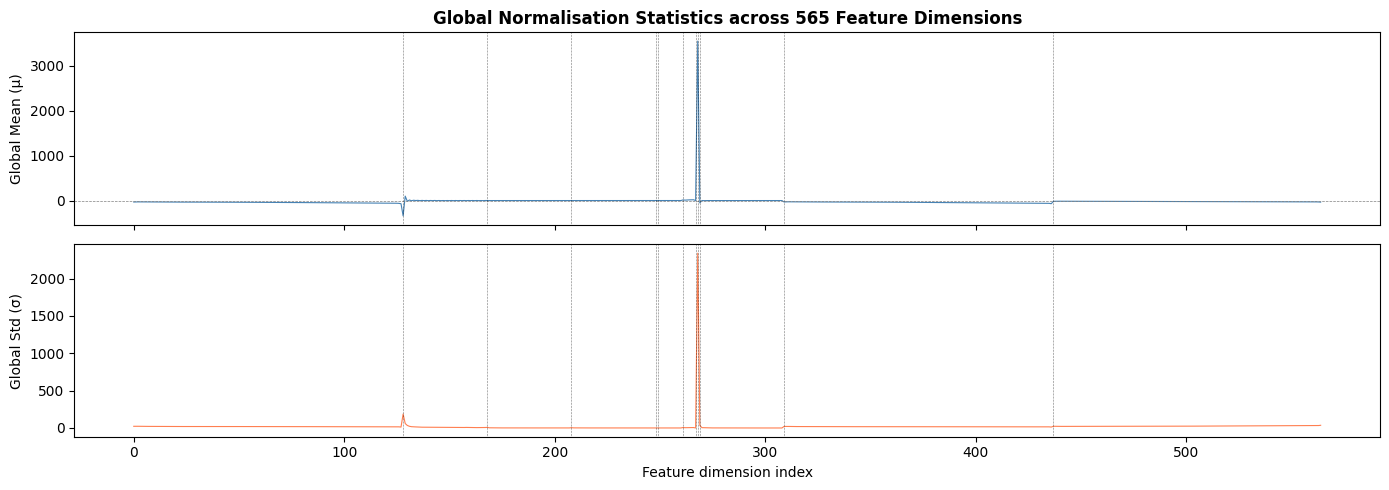

Saved → normalisation_stats.png


In [19]:
# ── 5e · Visualise normalisation effect ───────────────────────────────────────
# Show mean and std across all 565 feature dimensions
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(GLOBAL_MU,  color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Global Mean (μ)', fontsize=10)
axes[0].set_title('Global Normalisation Statistics across 565 Feature Dimensions',
                   fontsize=12, fontweight='bold')

axes[1].plot(GLOBAL_STD, color='coral', linewidth=0.8)
axes[1].set_ylabel('Global Std (σ)', fontsize=10)
axes[1].set_xlabel('Feature dimension index', fontsize=10)

# Annotate feature group boundaries
boundaries = np.cumsum([128, 40, 40, 40, 1, 12, 6, 1, 1, 40, 128])
labels_b   = ['Mel|', 'MFCC|', 'Δ|', 'ΔΔ|', 'RMS|', 'Chr|', 'Con|', 'ZCR|', 'Roll|', 'GFCC|', 'Mel-S|']
for ax in axes:
    for b, lbl in zip(boundaries, labels_b):
        ax.axvline(b, color='black', linewidth=0.4, linestyle=':')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'normalisation_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → normalisation_stats.png")


---
## 6 · Augmentation Strategy

### 6.1 Explanation

Augmentation is applied **in the feature domain** during training only, operating on the normalised (T × 565) feature matrix.  
Four complementary strategies are used:

| Strategy | Where applied | What it does | Why it helps |
|---|---|---|---|
| **SpecAugment** (time masking) | Time axis | Randomly zeros up to 25 consecutive frames (≈ 0.6 s) | Forces the model to classify from partial temporal context; prevents over-reliance on any single short segment |
| **SpecAugment** (frequency masking) | Feature axis | Randomly zeros up to 30 consecutive feature dimensions | Prevents over-fitting to specific frequency bands; mimics partial occlusion |
| **Gaussian noise** | Entire matrix | Adds N(0, 0.05) noise with prob = 0.4 | Smooths decision boundary; reduces sensitivity to minor measurement variations |
| **Amplitude scaling** | Entire matrix | Multiplies by Uniform(0.75, 1.25) with prob = 0.4 | Simulates recording level variation across microphones / environments |
| **Mixup** (batch-level) | Batch of features + labels | x̃ = λ·xᵢ + (1−λ)·xⱼ; ỹ = λ·yᵢ + (1−λ)·yⱼ with λ~Beta(0.4,0.4) | Strong regulariser — creates an infinite set of convex combinations; reduces over-confidence and calibrates probabilities |

**Implementation detail:** SpecAugment, noise, and amplitude scaling are applied inside `UrbanSoundDataset.__getitem__` (sample level).  
Mixup is applied inside `train_one_epoch` (batch level) because it requires pairs of samples.  
Validation and test sets receive **no augmentation**.


In [20]:
# ── 6 · Dataset class with augmentation ──────────────────────────────────────
class UrbanSoundDataset(Dataset):
    """
    UrbanSound8K loader.
    Normalisation: (ft − GLOBAL_MU) / GLOBAL_STD applied to every sample.
    Augmentation:  SpecAugment + Gaussian noise + amplitude scaling (train only).
    """
    def __init__(self, meta, folds, cache_dir, max_len=MAX_LEN,
                 global_mu=None, global_std=None, augment=False):
        self.cache_dir  = cache_dir
        self.max_len    = max_len
        self.augment    = augment
        self.global_mu  = global_mu
        self.global_std = global_std
        self.records    = meta[meta['fold'].isin(folds)].reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def _spec_augment(self, ft):
        ft = ft.copy()
        T, F = ft.shape
        # Time masking
        if random.random() < 0.6:
            t_w = random.randint(5, 25)
            t_s = random.randint(0, max(0, T - t_w))
            ft[t_s:t_s+t_w, :] = 0.0
        # Frequency masking
        if random.random() < 0.6:
            f_w = random.randint(5, 30)
            f_s = random.randint(0, max(0, F - f_w))
            ft[:, f_s:f_s+f_w] = 0.0
        # Gaussian noise
        if random.random() < 0.4:
            ft += np.random.normal(0, 0.05, ft.shape).astype(np.float32)
        # Amplitude scaling
        if random.random() < 0.4:
            ft *= random.uniform(0.75, 1.25)
        return ft

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        ft  = np.load(str(self.cache_dir / f"{row['fold']}_{row['slice_file_name']}.npy"))

        # Global normalisation
        if self.global_mu is not None:
            ft = (ft - self.global_mu[None, :]) / self.global_std[None, :]
        else:
            mu = ft.mean(0, keepdims=True); sigma = ft.std(0, keepdims=True) + 1e-8
            ft = (ft - mu) / sigma

        # Pad / truncate
        T = ft.shape[0]
        if T < self.max_len:
            ft = np.vstack([ft, np.zeros((self.max_len-T, ft.shape[1]), dtype=np.float32)])
        else:
            ft = ft[:self.max_len]

        if self.augment:
            ft = self._spec_augment(ft)

        return (torch.tensor(ft, dtype=torch.float32),
                torch.tensor(int(row['classID']), dtype=torch.long))


def make_loader(meta, folds, batch_size=32, shuffle=True, augment=False):
    ds = UrbanSoundDataset(meta, folds, CACHE_DIR,
                            global_mu=GLOBAL_MU, global_std=GLOBAL_STD,
                            augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=False)


# Batch shape check
_tmp = make_loader(meta, TRAIN_FOLDS[:1], batch_size=4, shuffle=False)
xb, yb = next(iter(_tmp)); del _tmp
print(f"Batch shapes → X: {xb.shape}  y: {yb.shape} ✓")


Batch shapes → X: torch.Size([4, 173, 565])  y: torch.Size([4]) ✓


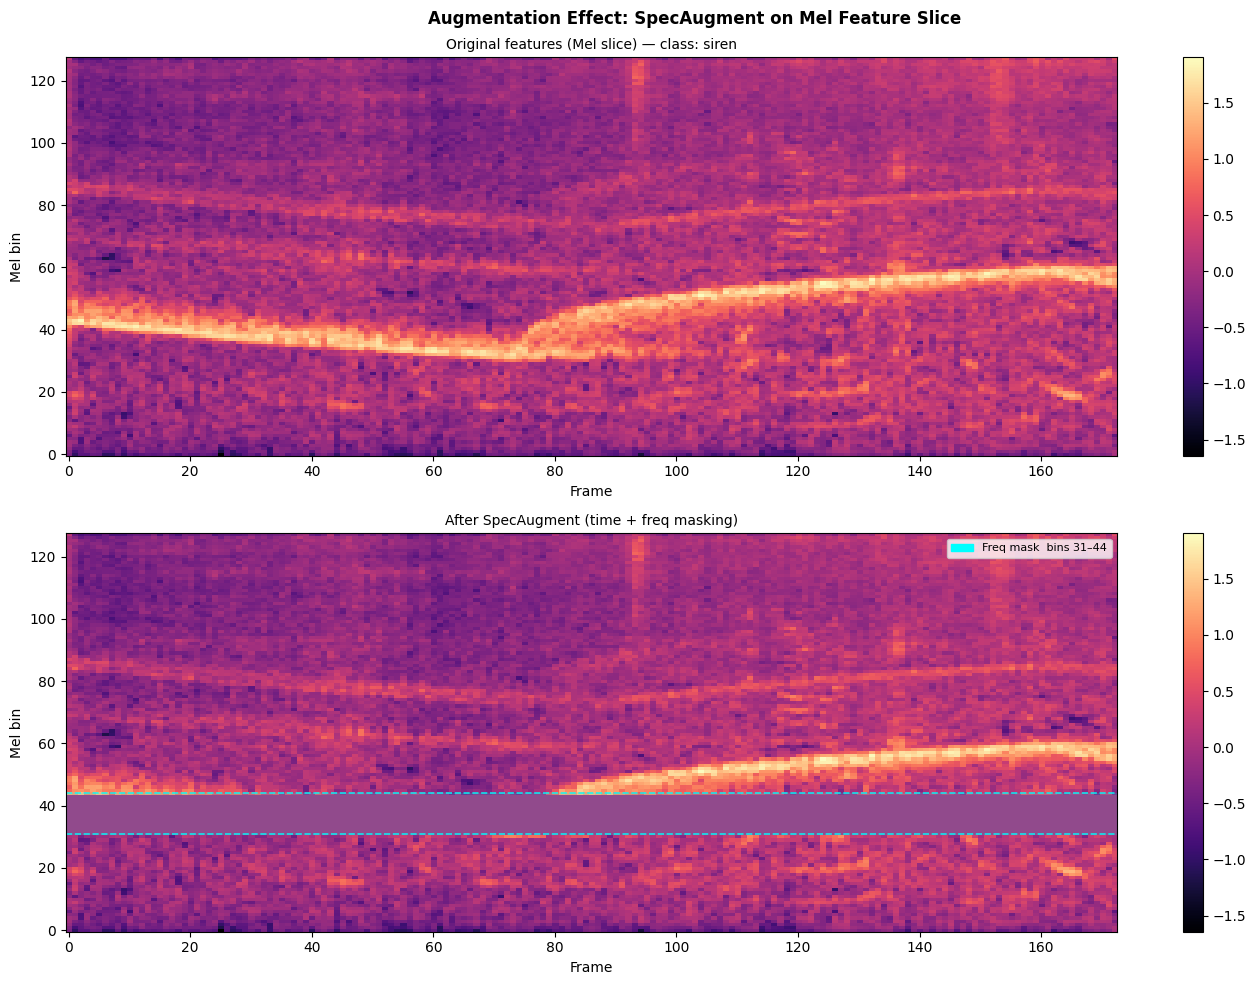

Saved → augmentation_example.png


In [21]:
# ── 6b · Visualise Mixup (batch-level) ────────────────────────────────────────
# Shows how a pair of samples are blended at λ = 0.6

# Visualise SpecAugment effect
_loader = make_loader(meta, TRAIN_FOLDS, batch_size=1, shuffle=True, augment=False)
x_orig, y_orig = next(iter(_loader))
x_aug  = UrbanSoundDataset.__new__(UrbanSoundDataset)
x_aug._spec_augment = UrbanSoundDataset._spec_augment.__get__(x_aug, UrbanSoundDataset)
ft_orig = x_orig[0].numpy()
# Run augment manually so we can capture the mask coordinates
ft_aug = ft_orig.copy()
T, FEAT_DIM = ft_aug.shape
PLOT_F = 128
t_start = t_end = f_start = f_end = None

if random.random() < 0.6:
    t_w = random.randint(5, 25)
    t_start = random.randint(0, max(0, T - t_w))
    t_end = t_start + t_w
    ft_aug[t_start:t_end, :] = 0.0

if random.random() < 0.6:
    f_w = random.randint(5, 30)
    f_start = random.randint(0, max(0, PLOT_F - f_w))
    f_end = f_start + f_w
    ft_aug[:, f_start:f_end] = 0.0

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
im0 = axes[0].imshow(ft_orig[:, :128].T, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title(f'Original features (Mel slice) — class: {CLASS_NAMES[y_orig.item()]}', fontsize=10)
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Mel bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ft_aug[:, :128].T,  aspect='auto', origin='lower', cmap='magma')
from matplotlib.patches import Patch
legend_handles = []
if t_start is not None:
    axes[1].axvline(t_start, color='red', linewidth=1.2, linestyle='--', alpha=0.85)
    axes[1].axvline(t_end,   color='red', linewidth=1.2, linestyle='--', alpha=0.85)
    axes[1].axvspan(t_start, t_end, color='red', alpha=0.12)
    legend_handles.append(Patch(color='red', label=f'Time mask  frames {t_start}–{t_end}'))
if f_start is not None:
    axes[1].axhline(f_start, color='cyan', linewidth=1.2, linestyle='--', alpha=0.85)
    axes[1].axhline(f_end,   color='cyan', linewidth=1.2, linestyle='--', alpha=0.85)
    axes[1].axhspan(f_start, f_end, color='cyan', alpha=0.12)
    legend_handles.append(Patch(color='cyan', label=f'Freq mask  bins {f_start}–{f_end}'))
if legend_handles:
    axes[1].legend(handles=legend_handles, fontsize=8, loc='upper right')
axes[1].set_title('After SpecAugment (time + freq masking)', fontsize=10)
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Mel bin')
fig.colorbar(im1, ax=axes[1])

fig.suptitle('Augmentation Effect: SpecAugment on Mel Feature Slice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_example.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → augmentation_example.png")
del _loader


---
## 7 · Model Architecture and Training Phase

### 7.1 Model Explanation

Two model families are trained — both are GRU-based as required by the assignment constraints.

---

#### 7.1.1 EnhancedGRUClassifier

```
Input  (B, T, 565)
  │
  ├─ Linear projection  565 → hidden_dim
  │
  ├─ Bidirectional GRU  (n_layers layers, dropout between layers)
  │    Output: (B, T, hidden_dim × 2)
  │
  ├─ Multi-head Attention Pooling  (4 independent heads)
  │    Each head: linear score → softmax → weighted sum
  │    Concatenated → projected back to hidden_dim × 2
  │    Output: (B, hidden_dim × 2)
  │
  ├─ Residual skip from Linear projection (projected to GRU output dim)
  │
  ├─ BatchNorm1d
  │
  └─ Head: Dropout → FC → GELU → Dropout → FC(10)
```

**Key design choices:**
- **Multi-head attention** (4 heads) allows the model to attend to different temporal positions simultaneously — one head may focus on the onset, another on the steady-state, another on the offset.
- **Residual projection** from input to GRU output provides a direct gradient path and alleviates vanishing-gradient issues in deeper GRU stacks.
- **Dropout 0.3** (vs. 0.5 in baseline) — the baseline's aggressive dropout caused under-fitting after ~40 epochs; reducing it lets the model continue converging.

---

#### 7.1.2 DeepCNNGRUClassifier

```
Input  (B, T, 565)
  │
  ├─ Permute  →  (B, 565, T)  [Conv1d expects channels first]
  │
  ├─ ResConvBlock  565 → 64    [Conv1d × 2 + BN + GELU + SE attention + skip]
  ├─ ResConvBlock   64 → 128
  ├─ ResConvBlock  128 → 256
  │
  ├─ MaxPool1d(2)  →  T // 2  [halves sequence length for GRU efficiency]
  │
  ├─ Permute  →  (B, T//2, 256)
  │
  ├─ Bidirectional GRU  (n_layers layers)
  │    Output: (B, T//2, hidden_dim × 2)
  │
  ├─ Multi-head Attention Pooling
  │
  ├─ BatchNorm1d
  │
  └─ Head: Dropout → FC → GELU → Dropout → FC(10)
```

**Key design choices:**
- **Residual CNN blocks** learn local temporal patterns (onset shapes, modulation rhythms) before the GRU models long-range dependencies.
- **Squeeze-and-Excitation (SE) attention** inside each ResConvBlock recalibrates channel-wise feature importance — essentially learning which of the 128/256 convolutional filters are most discriminative for each clip.
- **MaxPool1d(2)** after the CNN reduces T//2 for the GRU, cutting GRU computation in half with minimal information loss (the CNN has already summarised local context).

---

#### 7.1.3 Training configuration

| Setting | Value | Rationale |
|---|---|---|
| Optimizer | AdamW (wd = 5e-4) | Weight decay decoupled from gradient update |
| Loss | Label-smoothed CE (ε=0.1) | Prevents over-confident predictions; better calibration |
| Mixup | α = 0.4 | Strong regulariser via soft interpolated labels |
| LR scheduler | Cosine + 5-epoch warmup | Stable early training; smooth decay |
| Secondary scheduler | ReduceLROnPlateau (×0.5, patience=5) | Rescues stalled training |
| Gradient clipping | max_norm = 5.0 | Prevents GRU gradient explosions |
| Epochs | 100 max | Extended budget for slower-learning CNN-GRU configs |
| Early stopping | patience = 15 on val loss | Stops before significant over-fitting |


In [22]:
# ── 7a · Attention pooling module ────────────────────────────────────────────
class MultiHeadAttentionPool(nn.Module):
    """4-head temporal attention pooling over sequence dimension."""
    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.W         = nn.Linear(dim, num_heads)   # one score per head
        self.proj      = nn.Linear(dim, dim)

    def forward(self, x):
        # x: (B, T, dim)
        scores  = self.W(x)                      # (B, T, H)
        weights = torch.softmax(scores, dim=1)   # (B, T, H)
        heads   = []
        for h in range(self.num_heads):
            ctx = (x * weights[:, :, h:h+1]).sum(dim=1)   # (B, dim)
            heads.append(ctx)
        out = torch.stack(heads, dim=1).mean(dim=1)        # (B, dim)
        return self.proj(out)


In [23]:
# ── 7b · EnhancedGRUClassifier ────────────────────────────────────────────────
class EnhancedGRUClassifier(nn.Module):
    """
    Bidirectional GRU with multi-head attention pooling and residual skip.
    input_dim → Linear → BiGRU → MH-Attn → BN → Head → 10 logits
    """
    def __init__(self, input_dim=FEATURE_DIM, hidden_dim=256, n_layers=2,
                 dropout=0.3, num_classes=NUM_CLASSES, attn_heads=4):
        super().__init__()
        gru_out   = hidden_dim * 2
        self.proj = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                   nn.LayerNorm(hidden_dim),
                                   nn.GELU())
        self.gru  = nn.GRU(hidden_dim, hidden_dim, n_layers,
                            batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0,
                            bidirectional=True)
        self.skip      = nn.Linear(hidden_dim, gru_out)
        self.attn_pool = MultiHeadAttentionPool(gru_out, num_heads=attn_heads)
        self.bn        = nn.BatchNorm1d(gru_out)
        self.head      = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out, 256), nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(256, num_classes))

    def forward(self, x):
        p   = self.proj(x)                         # (B, T, hidden)
        out, _ = self.gru(p)                       # (B, T, 2*hidden)
        ctx = self.attn_pool(out) + self.skip(p.mean(dim=1))   # residual
        return self.head(self.bn(ctx))


# Parameter count
_m = EnhancedGRUClassifier()
print(f"EnhancedGRUClassifier — params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m


EnhancedGRUClassifier — params: 2,648,846


In [24]:
# ── 7c · DeepCNNGRUClassifier ────────────────────────────────────────────────
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention for Conv1d."""
    def __init__(self, ch, r=8):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ch, max(1, ch//r)), nn.GELU(),
                                 nn.Linear(max(1, ch//r), ch), nn.Sigmoid())
    def forward(self, x):            # x: (B, C, T)
        g = x.mean(-1)               # (B, C)
        s = self.fc(g).unsqueeze(-1) # (B, C, 1)
        return x * s


class ResConvBlock(nn.Module):
    """Residual 1-D Conv block: 2×[Conv→BN→GELU] + SE + skip."""
    def __init__(self, in_ch, out_ch, kernel=5):
        super().__init__()
        pad       = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad), nn.BatchNorm1d(out_ch), nn.GELU(),
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad), nn.BatchNorm1d(out_ch))
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.se   = SEBlock(out_ch)
        self.act  = nn.GELU()

    def forward(self, x):
        return self.act(self.se(self.conv(x)) + self.skip(x))


class DeepCNNGRUClassifier(nn.Module):
    """
    3× ResConvBlock (SE attention) + MaxPool + Bidirectional GRU + MH-Attn + Head.
    """
    def __init__(self, input_dim=FEATURE_DIM, hidden_dim=256, n_layers=3,
                 dropout=0.3, num_classes=NUM_CLASSES, attn_heads=4):
        super().__init__()
        gru_out    = hidden_dim * 2
        self.cnn   = nn.Sequential(ResConvBlock(input_dim, 64),
                                    ResConvBlock(64, 128),
                                    ResConvBlock(128, 256))
        self.pool  = nn.MaxPool1d(kernel_size=2, stride=2)
        self.gru   = nn.GRU(256, hidden_dim, n_layers, batch_first=True,
                             dropout=dropout if n_layers > 1 else 0.0,
                             bidirectional=True)
        self.attn_pool = MultiHeadAttentionPool(gru_out, num_heads=attn_heads)
        self.bn        = nn.BatchNorm1d(gru_out)
        self.head      = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out, 256), nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = x.permute(0, 2, 1)         # (B, F, T)
        x = self.pool(self.cnn(x))      # (B, 256, T//2)
        x = x.permute(0, 2, 1)         # (B, T//2, 256)
        out, _ = self.gru(x)            # (B, T//2, 2*hidden)
        ctx    = self.attn_pool(out)
        return self.head(self.bn(ctx))


_m2 = DeepCNNGRUClassifier()
print(f"DeepCNNGRUClassifier — params: {sum(p.numel() for p in _m2.parameters() if p.requires_grad):,}")
del _m2


DeepCNNGRUClassifier — params: 4,472,518


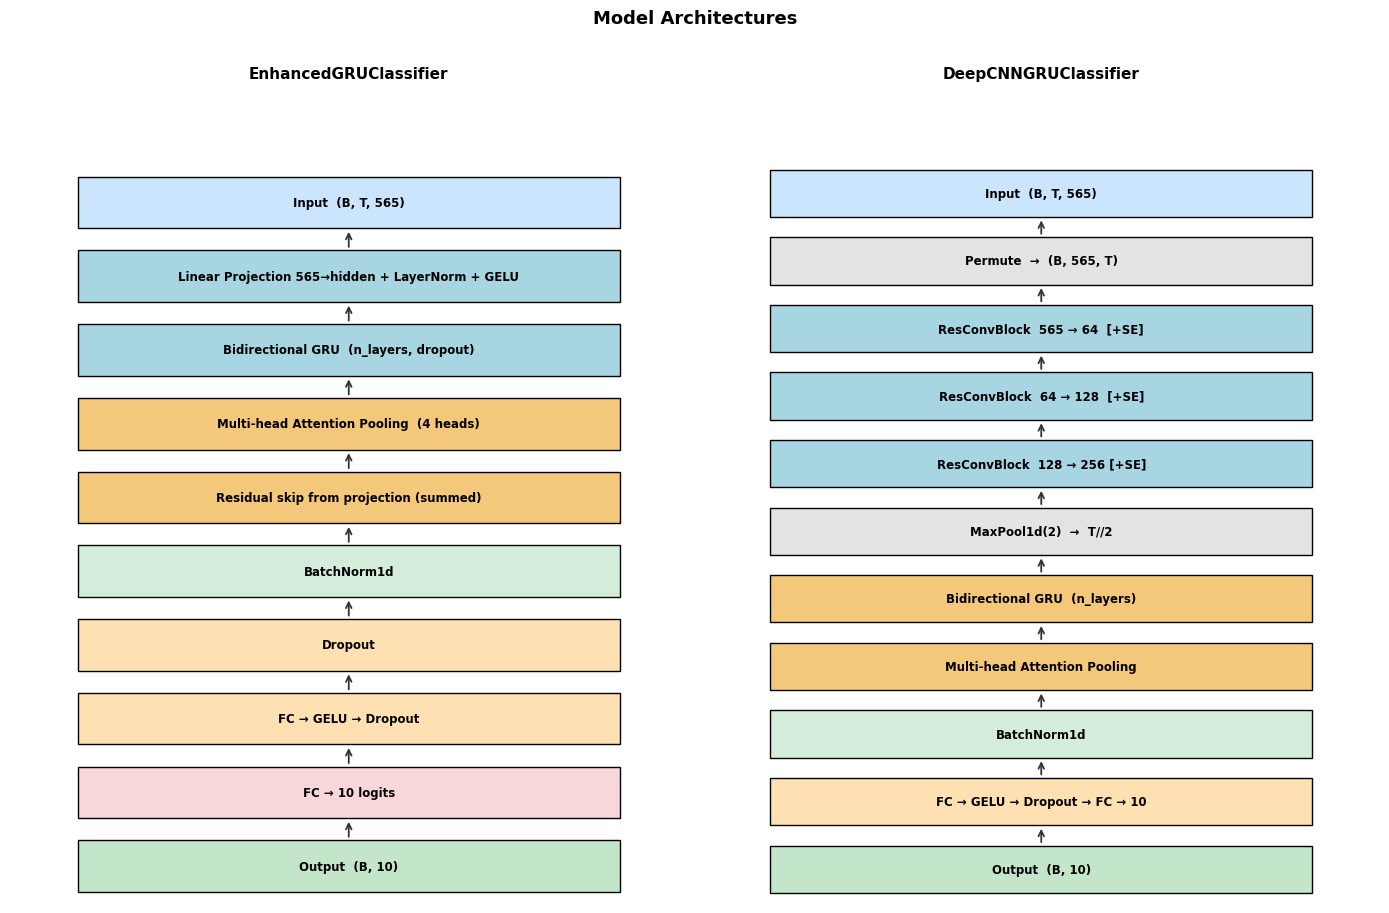

Saved → model_architectures.png


In [25]:
# ── 7d · Visualise model architecture (block diagram) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

def draw_arch(ax, blocks, title, colors):
    ax.set_xlim(0, 4); ax.set_ylim(-0.5, len(blocks) + 0.5)
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    for i, (lbl, col) in enumerate(zip(blocks, colors)):
        y = len(blocks) - i - 1
        rect = plt.Rectangle((0.4, y - 0.35), 3.2, 0.7, facecolor=col,
                               edgecolor='black', linewidth=1.0, zorder=2)
        ax.add_patch(rect)
        ax.text(2.0, y, lbl, ha='center', va='center', fontsize=8.5,
                fontweight='bold', zorder=3)
        if i < len(blocks) - 1:
            ax.annotate('', xy=(2.0, y - 0.36), xytext=(2.0, y - 0.64),
                        arrowprops=dict(arrowstyle='->', color='#333333', lw=1.3))

gru_blocks  = ['Input  (B, T, 565)', 'Linear Projection 565→hidden + LayerNorm + GELU',
               'Bidirectional GRU  (n_layers, dropout)',
               'Multi-head Attention Pooling  (4 heads)',
               'Residual skip from projection (summed)',
               'BatchNorm1d', 'Dropout', 'FC → GELU → Dropout', 'FC → 10 logits',
               'Output  (B, 10)']
gru_colors  = ['#cce5ff', '#a8d5e2', '#a8d5e2', '#f4c87b', '#f4c87b',
               '#d4edda', '#ffe0b2', '#ffe0b2', '#f8d7da', '#c3e6cb']

cnn_blocks  = ['Input  (B, T, 565)',
               'Permute  →  (B, 565, T)',
               'ResConvBlock  565 → 64  [+SE]',
               'ResConvBlock  64 → 128  [+SE]',
               'ResConvBlock  128 → 256 [+SE]',
               'MaxPool1d(2)  →  T//2',
               'Bidirectional GRU  (n_layers)',
               'Multi-head Attention Pooling',
               'BatchNorm1d',
               'FC → GELU → Dropout → FC → 10',
               'Output  (B, 10)']
cnn_colors  = ['#cce5ff', '#e2e3e5', '#a8d5e2', '#a8d5e2', '#a8d5e2',
               '#e2e3e5', '#f4c87b', '#f4c87b', '#d4edda', '#ffe0b2', '#c3e6cb']

draw_arch(axes[0], gru_blocks, 'EnhancedGRUClassifier', gru_colors)
draw_arch(axes[1], cnn_blocks, 'DeepCNNGRUClassifier', cnn_colors)

plt.suptitle('Model Architectures', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_architectures.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → model_architectures.png")


In [26]:
# ── 7e · Training utilities ───────────────────────────────────────────────────
class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing (ε = smoothing)."""
    def __init__(self, num_classes=NUM_CLASSES, smoothing=0.1):
        super().__init__()
        self.nc = num_classes; self.s = smoothing
    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        if targets.dim() == 1:
            smooth_val = self.s / (self.nc - 1)
            soft = torch.full_like(log_p, smooth_val)
            soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.s)
        else:
            soft = targets
        return -(soft * log_p).sum(dim=-1).mean()


def mixup_batch(xb, yb, alpha=0.4, nc=NUM_CLASSES):
    if alpha <= 0: return xb, F.one_hot(yb, nc).float()
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(xb.size(0), device=xb.device)
    return (lam*xb + (1-lam)*xb[idx],
            lam*F.one_hot(yb,nc).float() + (1-lam)*F.one_hot(yb[idx],nc).float())


def train_one_epoch(model, loader, optimizer, criterion, device,
                    use_mixup=True, alpha=0.4):
    model.train(); total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if use_mixup: xb, yb = mixup_batch(xb, yb, alpha)
        else: yb = F.one_hot(yb, NUM_CLASSES).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); total_loss = 0.0; all_p, all_l = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += F.cross_entropy(logits, yb).item() * xb.size(0)
        all_p.extend(logits.argmax(1).cpu().numpy())
        all_l.extend(yb.cpu().numpy())
    n = len(loader.dataset)
    return (total_loss/n,
            accuracy_score(all_l, all_p),
            f1_score(all_l, all_p, average='macro', zero_division=0),
            all_l, all_p)

print("Training utilities defined ✓")


Training utilities defined ✓


In [27]:
# ── 7f · Hyperparameter grid & training loop ──────────────────────────────────
HP_GRID = [
    (EnhancedGRUClassifier,  'GRU-256-2-do30',       256, 2, 0.30, 3e-4, 64),
    (EnhancedGRUClassifier,  'GRU-256-3-do30',       256, 3, 0.30, 3e-4, 64),
    (EnhancedGRUClassifier,  'GRU-256-2-lr2e4',      256, 2, 0.30, 2e-4, 64),
    (EnhancedGRUClassifier,  'GRU-256-4-lr2e4',      256, 4, 0.30, 2e-4, 64),
    (EnhancedGRUClassifier,  'GRU-512-3-lr2e4',      512, 3, 0.30, 2e-4, 64),
    (DeepCNNGRUClassifier,   'DCNNGRU-256-2-do30',   256, 2, 0.30, 3e-4, 64),
    (DeepCNNGRUClassifier,   'DCNNGRU-256-3-do30',   256, 3, 0.30, 2e-4, 64),
    (DeepCNNGRUClassifier,   'DCNNGRU-512-3-do30',   512, 3, 0.30, 2e-4, 64),
    (DeepCNNGRUClassifier,   'DCNNGRU-256-4-do30',   256, 4, 0.30, 2e-4, 64),
]

MAX_EPOCHS  = 100
PATIENCE    = 15
MIXUP_ALPHA = 0.4

ANALYTICS         = {}
BEST_MODEL_STATE  = None
BEST_MODEL_CLASS  = None
BEST_MODEL_KWARGS = None
BEST_VAL_ACC      = -1.0
BEST_LABEL        = ''

criterion  = LabelSmoothingCrossEntropy(NUM_CLASSES, 0.1)
val_loader = make_loader(meta, VAL_FOLDS, batch_size=128, shuffle=False)

for (ModelClass, label, hidden, n_layers, dropout, lr, batch_size) in HP_GRID:
    print(f"\n{'='*65}")
    print(f"  Config: {label}  hidden={hidden} layers={n_layers} lr={lr}")
    print(f"{'='*65}")
    torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

    mkw   = dict(input_dim=FEATURE_DIM, hidden_dim=hidden, n_layers=n_layers,
                 dropout=dropout, num_classes=NUM_CLASSES, attn_heads=4)
    model = ModelClass(**mkw).to(DEVICE)
    n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {n_p:,}")

    optim_ = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)

    WARMUP = 5
    def lr_lambda(epoch):
        if epoch < WARMUP: return (epoch+1)/WARMUP
        return 0.5*(1+np.cos(np.pi*(epoch-WARMUP)/max(1,MAX_EPOCHS-WARMUP)))

    sched_cos  = optim.lr_scheduler.LambdaLR(optim_, lr_lambda)
    sched_plat = optim.lr_scheduler.ReduceLROnPlateau(optim_, mode='min',
                     factor=0.5, patience=5, min_lr=1e-6)
    train_loader = make_loader(meta, TRAIN_FOLDS, batch_size, shuffle=True, augment=True)

    tr_losses, vl_losses, vl_accs, vl_f1s = [], [], [], []
    best_vl_loss   = float('inf'); best_state = None
    best_vacc = best_vf1 = best_ep = patience_ctr = 0
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS+1):
        tl  = train_one_epoch(model, train_loader, optim_, criterion, DEVICE,
                               use_mixup=True, alpha=MIXUP_ALPHA)
        vl, va, vf, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        sched_cos.step(); sched_plat.step(vl)

        tr_losses.append(tl); vl_losses.append(vl)
        vl_accs.append(va);   vl_f1s.append(vf)

        print(f"  Ep {epoch:3d}/{MAX_EPOCHS} | tr={tl:.4f} val={vl:.4f} "
              f"acc={va:.4f} F1={vf:.4f}")

        if vl < best_vl_loss - 1e-4:
            best_vl_loss = vl; best_vacc = va; best_vf1 = vf
            best_ep = epoch; patience_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  ↳ Early stop at epoch {epoch}"); break

    elapsed = time.time() - t0
    print(f"  ✓ Best acc={best_vacc:.4f}  F1={best_vf1:.4f}  ep={best_ep}  "
          f"time={elapsed:.0f}s")

    ANALYTICS[label] = dict(model=ModelClass.__name__, hidden=hidden,
        layers=n_layers, dropout=dropout, lr=lr, batch=batch_size,
        epochs_trained=epoch, best_epoch=best_ep, best_val_acc=best_vacc,
        best_val_f1=best_vf1, time_s=round(elapsed,1),
        train_losses=tr_losses, val_losses=vl_losses,
        val_accs=vl_accs, val_f1s=vl_f1s)

    if best_vacc > BEST_VAL_ACC:
        BEST_VAL_ACC = best_vacc; BEST_LABEL = label
        BEST_MODEL_STATE = best_state; BEST_MODEL_CLASS = ModelClass
        BEST_MODEL_KWARGS = mkw

    torch.save(best_state, str(OUTPUT_DIR / f'model_{label}.pt'))
    del model

print(f"\n{'='*65}")
print(f"  BEST CONFIG: {BEST_LABEL}  (val_acc = {BEST_VAL_ACC:.4f})")
print(f"{'='*65}")



  Config: GRU-256-2-do30  hidden=256 layers=2 lr=0.0003
  Params: 2,648,846
  Ep   1/100 | tr=1.7966 val=1.3921 acc=0.5730 F1=0.5676
  Ep   2/100 | tr=1.2800 val=1.1189 acc=0.6575 F1=0.6728
  Ep   3/100 | tr=1.1346 val=1.1293 acc=0.6423 F1=0.6695
  Ep   4/100 | tr=0.9437 val=1.1222 acc=0.6429 F1=0.6613
  Ep   5/100 | tr=0.8990 val=1.1607 acc=0.6387 F1=0.6417
  Ep   6/100 | tr=0.9454 val=1.0339 acc=0.6624 F1=0.6782
  Ep   7/100 | tr=0.8710 val=1.0879 acc=0.6764 F1=0.6874
  Ep   8/100 | tr=0.8037 val=1.0613 acc=0.6667 F1=0.6845
  Ep   9/100 | tr=0.8163 val=0.9532 acc=0.6953 F1=0.7121
  Ep  10/100 | tr=0.8065 val=0.9934 acc=0.6892 F1=0.7029
  Ep  11/100 | tr=0.7650 val=1.0302 acc=0.6807 F1=0.6977
  Ep  12/100 | tr=0.7488 val=1.0783 acc=0.6405 F1=0.6426
  Ep  13/100 | tr=0.6636 val=1.0773 acc=0.6594 F1=0.6694
  Ep  14/100 | tr=0.6615 val=1.0485 acc=0.6539 F1=0.6689
  Ep  15/100 | tr=0.7626 val=1.0390 acc=0.6642 F1=0.6769
  Ep  16/100 | tr=0.6355 val=0.9948 acc=0.6600 F1=0.6732
  Ep  17/10

---
## 8 · Learning Curves and Confusion Matrices

### 8.1 Explanation

**Learning curves** (train/val loss and val accuracy per epoch) let us diagnose:
- **Over-fitting** — train loss keeps falling while val loss rises
- **Under-fitting** — both losses plateau at a high value
- **Convergence** — both losses converge and stabilise
- **Effect of warmup** — the gradual LR rise visible in the first 5 epochs

We also show a **hyperparameter comparison table** and **validation confusion matrices** for all trained configurations, so we can see which classes each model finds hardest.


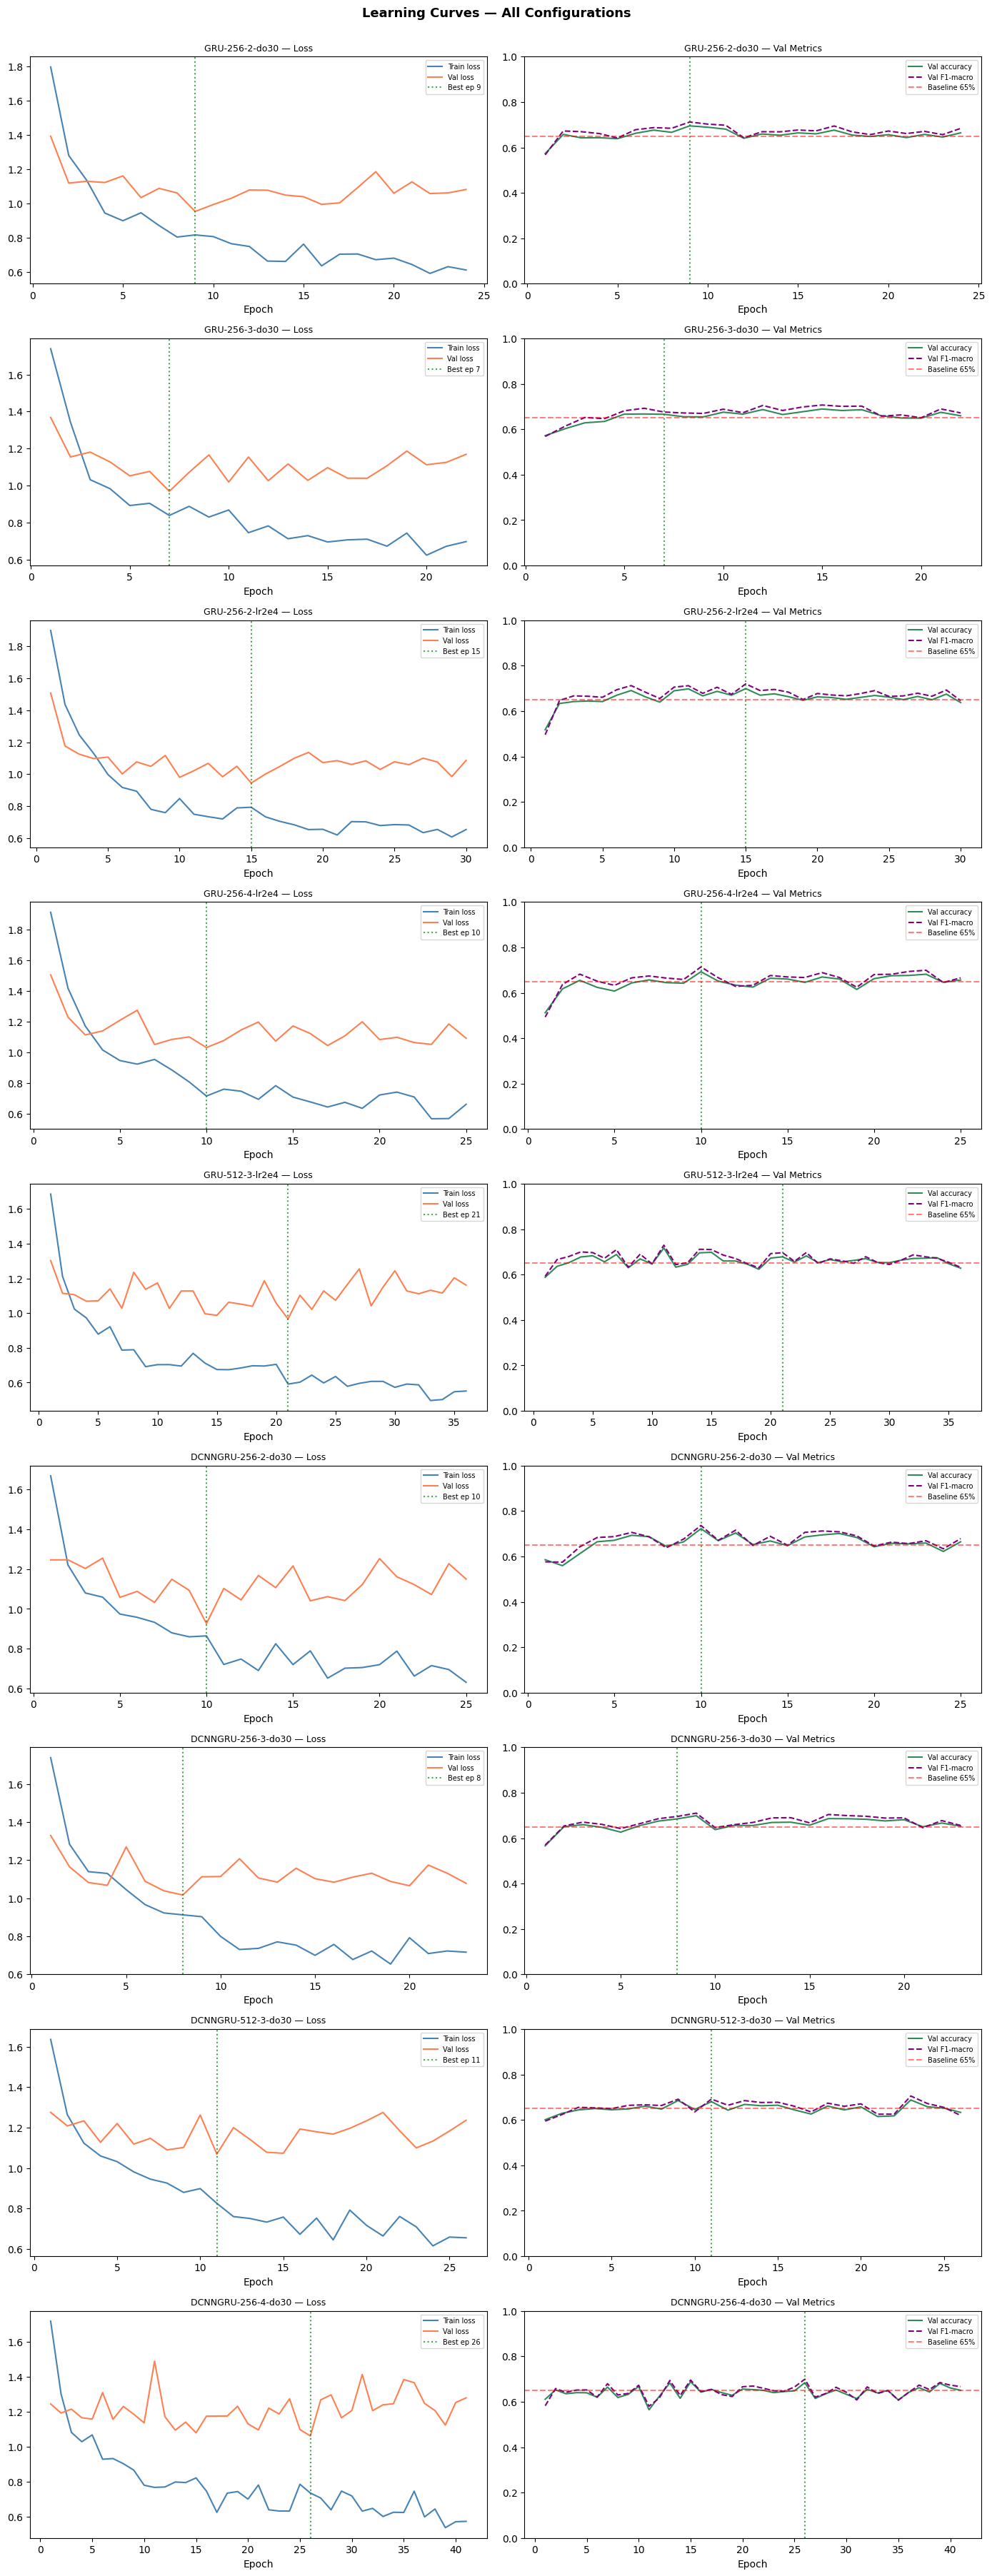

Saved → learning_curves.png


In [28]:
# ── 8a · Learning curves ─────────────────────────────────────────────────────
n_cfg = len(ANALYTICS)
fig, axes = plt.subplots(n_cfg, 2, figsize=(14, 4*n_cfg))
if n_cfg == 1: axes = axes[np.newaxis, :]

for ri, (label, info) in enumerate(ANALYTICS.items()):
    ep = range(1, info['epochs_trained']+1)
    ax_l, ax_a = axes[ri]

    ax_l.plot(ep, info['train_losses'], color='steelblue', label='Train loss')
    ax_l.plot(ep, info['val_losses'],   color='coral',     label='Val loss')
    ax_l.axvline(info['best_epoch'], color='green', ls=':', alpha=0.7,
                  label=f"Best ep {info['best_epoch']}")
    ax_l.set_title(f'{label} — Loss', fontsize=9)
    ax_l.set_xlabel('Epoch'); ax_l.legend(fontsize=7)

    ax_a.plot(ep, info['val_accs'], color='seagreen', label='Val accuracy')
    ax_a.plot(ep, info['val_f1s'],  color='purple', ls='--', label='Val F1-macro')
    ax_a.axvline(info['best_epoch'], color='green', ls=':', alpha=0.7)
    ax_a.axhline(0.65, color='red', ls='--', alpha=0.5, label='Baseline 65%')
    ax_a.set_title(f'{label} — Val Metrics', fontsize=9)
    ax_a.set_xlabel('Epoch'); ax_a.set_ylim(0, 1); ax_a.legend(fontsize=7)

plt.suptitle('Learning Curves — All Configurations', fontsize=13,
             fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()
print("Saved → learning_curves.png")


In [29]:
# ── 8b · HP comparison table ─────────────────────────────────────────────────
rows = [{'Config': lbl, 'Model': i['model'], 'hidden': i['hidden'],
         'layers': i['layers'], 'lr': i['lr'], 'batch': i['batch'],
         'epochs': i['epochs_trained'], 'best_val_acc': round(i['best_val_acc'],4),
         'best_val_F1': round(i['best_val_f1'],4), 'time_s': i['time_s']}
        for lbl, i in ANALYTICS.items()]

hp_df = (pd.DataFrame(rows)
           .sort_values('best_val_acc', ascending=False)
           .reset_index(drop=True))
hp_df.to_csv(OUTPUT_DIR / 'hp_comparison.csv', index=False)
print("Saved → hp_comparison.csv")
display(hp_df)


Saved → hp_comparison.csv


,Config,Model,hidden,layers,lr,batch,epochs,best_val_acc,best_val_F1,time_s
0,DCNNGRU-256-2-do30,DeepCNNGRUClassifier,256,2,0.0003,64,25,0.7220,0.7362,492.5
1,GRU-256-2-lr2e4,EnhancedGRUClassifier,256,2,0.0002,64,30,0.6989,0.7195,590.4
2,GRU-256-2-do30,EnhancedGRUClassifier,256,2,0.0003,64,24,0.6953,0.7121,472.1
3,GRU-256-4-lr2e4,EnhancedGRUClassifier,256,4,0.0002,64,25,0.6928,0.7140,602.9
4,DCNNGRU-256-3-do30,DeepCNNGRUClassifier,256,3,0.0002,64,23,0.6849,0.6956,455.3
5,DCNNGRU-256-4-do30,DeepCNNGRUClassifier,256,4,0.0002,64,41,0.6837,0.6993,859.6
6,DCNNGRU-512-3-do30,DeepCNNGRUClassifier,512,3,0.0002,64,26,0.6807,0.6918,767.5
7,GRU-512-3-lr2e4,EnhancedGRUClassifier,512,3,0.0002,64,36,0.6782,0.6964,1619.6
8,GRU-256-3-do30,EnhancedGRUClassifier,256,3,0.0003,64,22,0.6661,0.6759,468.0


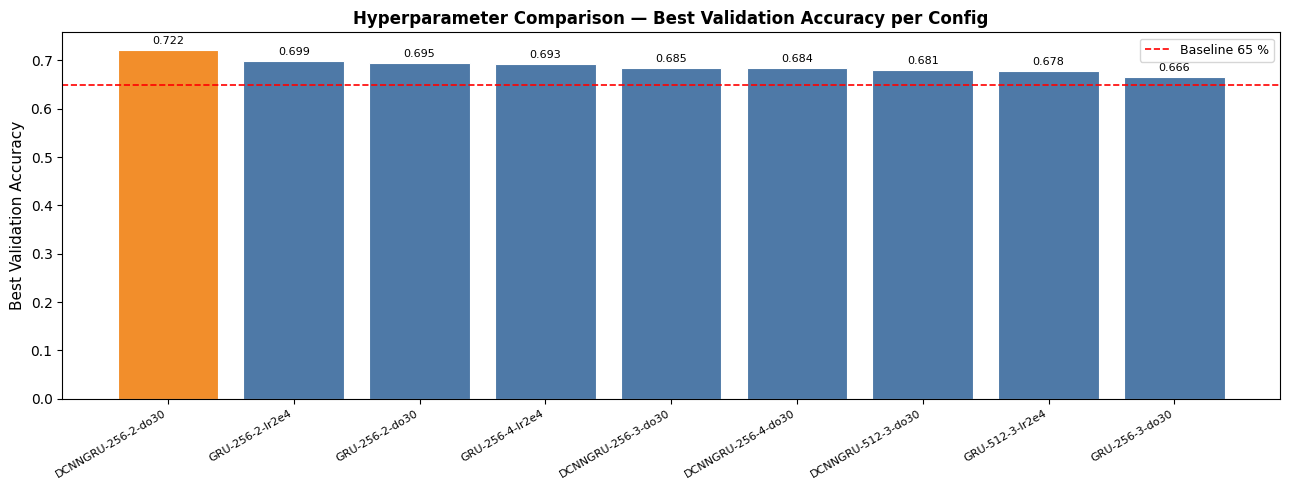

Saved → hp_comparison_bar.png


In [ ]:
# ── 8c · HP comparison bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sorted_labels = hp_df['Config'].tolist()
sorted_accs   = hp_df['best_val_acc'].tolist()
bar_colors    = ['#f28e2b' if lbl == BEST_LABEL else '#4e79a7' for lbl in sorted_labels]

bars = ax.bar(range(len(sorted_labels)), sorted_accs, color=bar_colors,
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=30, ha='right', fontsize=8)
ax.axhline(0.65, color='red', ls='--', lw=1.2, label='Baseline 65 %')
ax.set_ylabel('Best Validation Accuracy', fontsize=11)
ax.set_title('Hyperparameter Comparison — Best Validation Accuracy per Config',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hp_comparison_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → hp_comparison_bar.png")


In [ ]:
# ── 8d · Confusion matrix helper ──────────────────────────────────────────────
def plot_confusion_matrix(labels, preds, title, savepath=None):
    cm   = confusion_matrix(labels, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    sns.heatmap(cm,   annot=True, fmt='d',    ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5)
    axes[0].set_title(f'{title} — Raw Counts', fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    axes[0].set_yticklabels(CLASS_NAMES, rotation=0,  fontsize=8)

    sns.heatmap(cm_n, annot=True, fmt='.2f', ax=axes[1],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_title(f'{title} — Normalised (row)', fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    axes[1].set_yticklabels(CLASS_NAMES, rotation=0,  fontsize=8)

    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()

    # Print top confusions
    od = cm_n.copy(); np.fill_diagonal(od, 0)
    print("\nTop-5 most confused (true → predicted):")
    for _ in range(5):
        i, j = np.unravel_index(od.argmax(), od.shape)
        print(f"  {CLASS_NAMES[i]:20s} → {CLASS_NAMES[j]:20s}  ({od[i,j]:.2f})")
        od[i,j] = 0

print("Confusion matrix helper defined ✓")


Confusion matrix helper defined ✓



GRU-256-2-do30  val_acc=0.6953  val_F1=0.7121


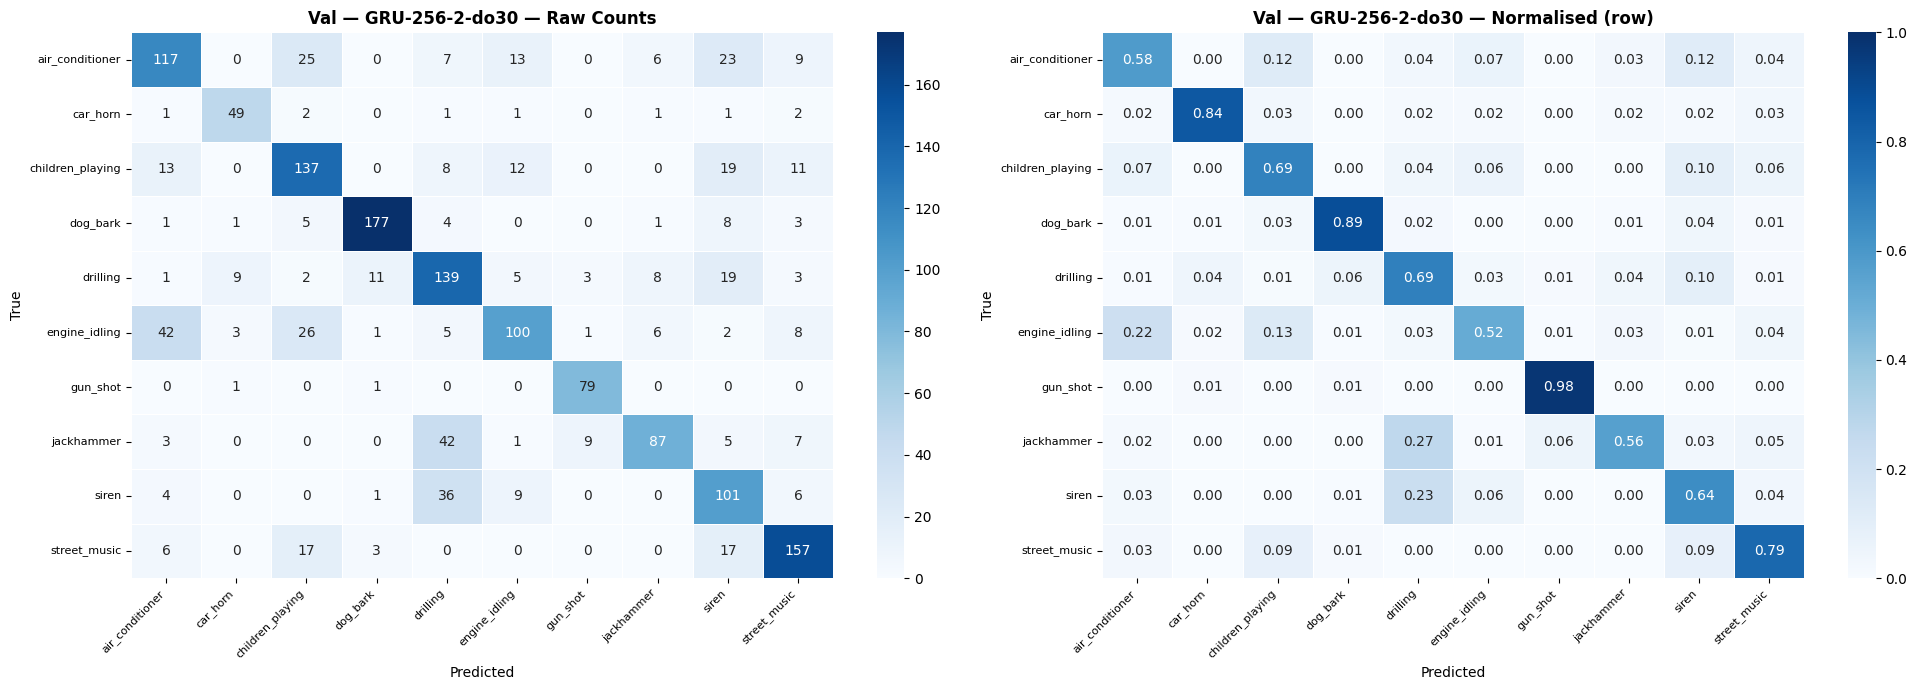


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.27)
  siren                → drilling              (0.23)
  engine_idling        → air_conditioner       (0.22)
  engine_idling        → children_playing      (0.13)
  air_conditioner      → children_playing      (0.12)

GRU-256-3-do30  val_acc=0.6661  val_F1=0.6759


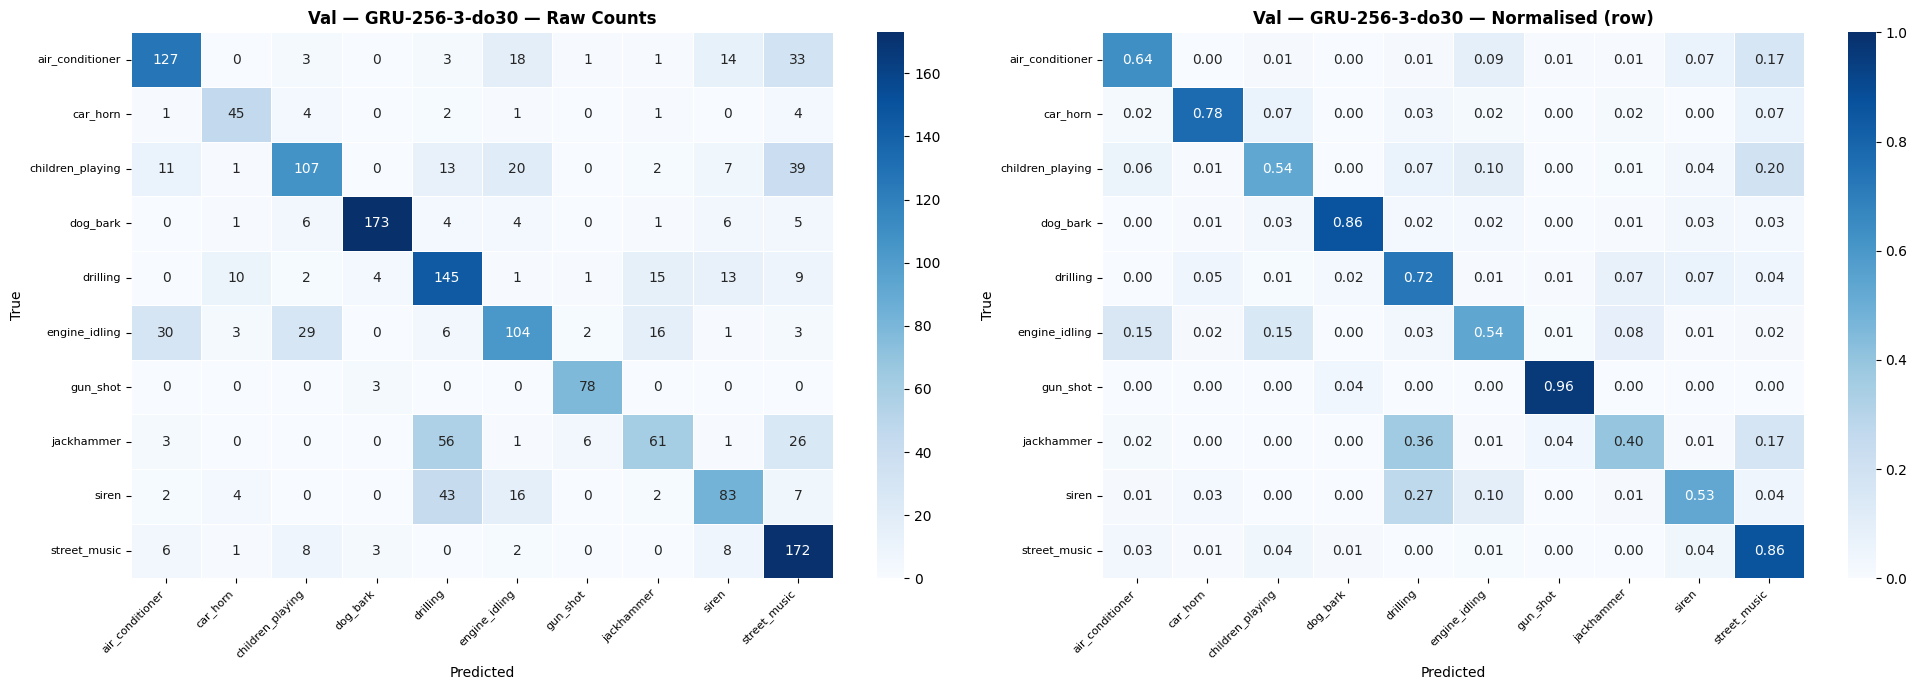


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.36)
  siren                → drilling              (0.27)
  children_playing     → street_music          (0.20)
  jackhammer           → street_music          (0.17)
  air_conditioner      → street_music          (0.17)

GRU-256-2-lr2e4  val_acc=0.6989  val_F1=0.7195


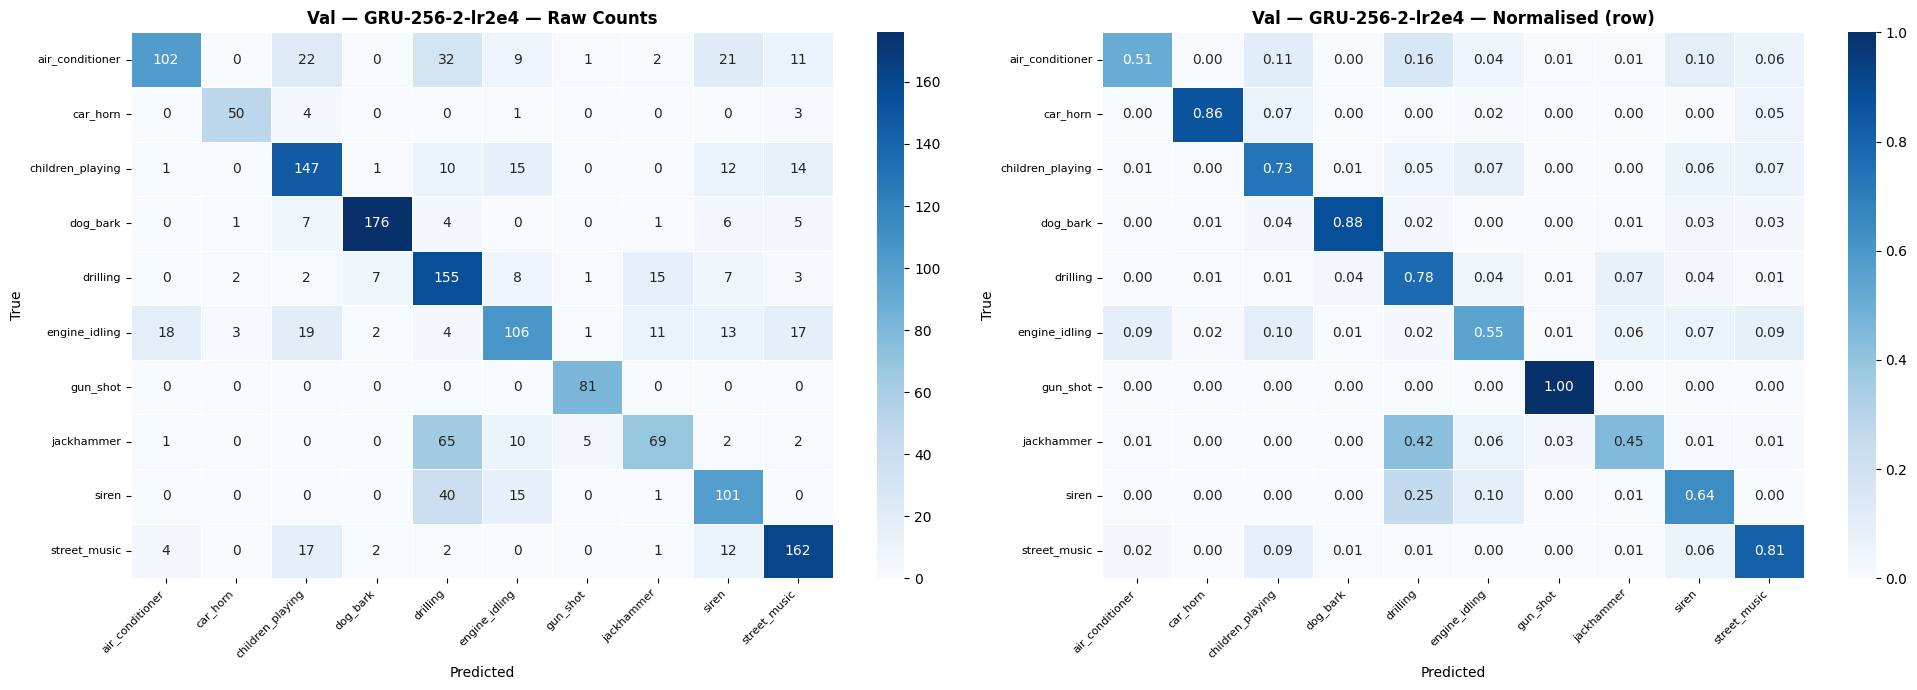


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.42)
  siren                → drilling              (0.25)
  air_conditioner      → drilling              (0.16)
  air_conditioner      → children_playing      (0.11)
  air_conditioner      → siren                 (0.10)

GRU-256-4-lr2e4  val_acc=0.6928  val_F1=0.7140


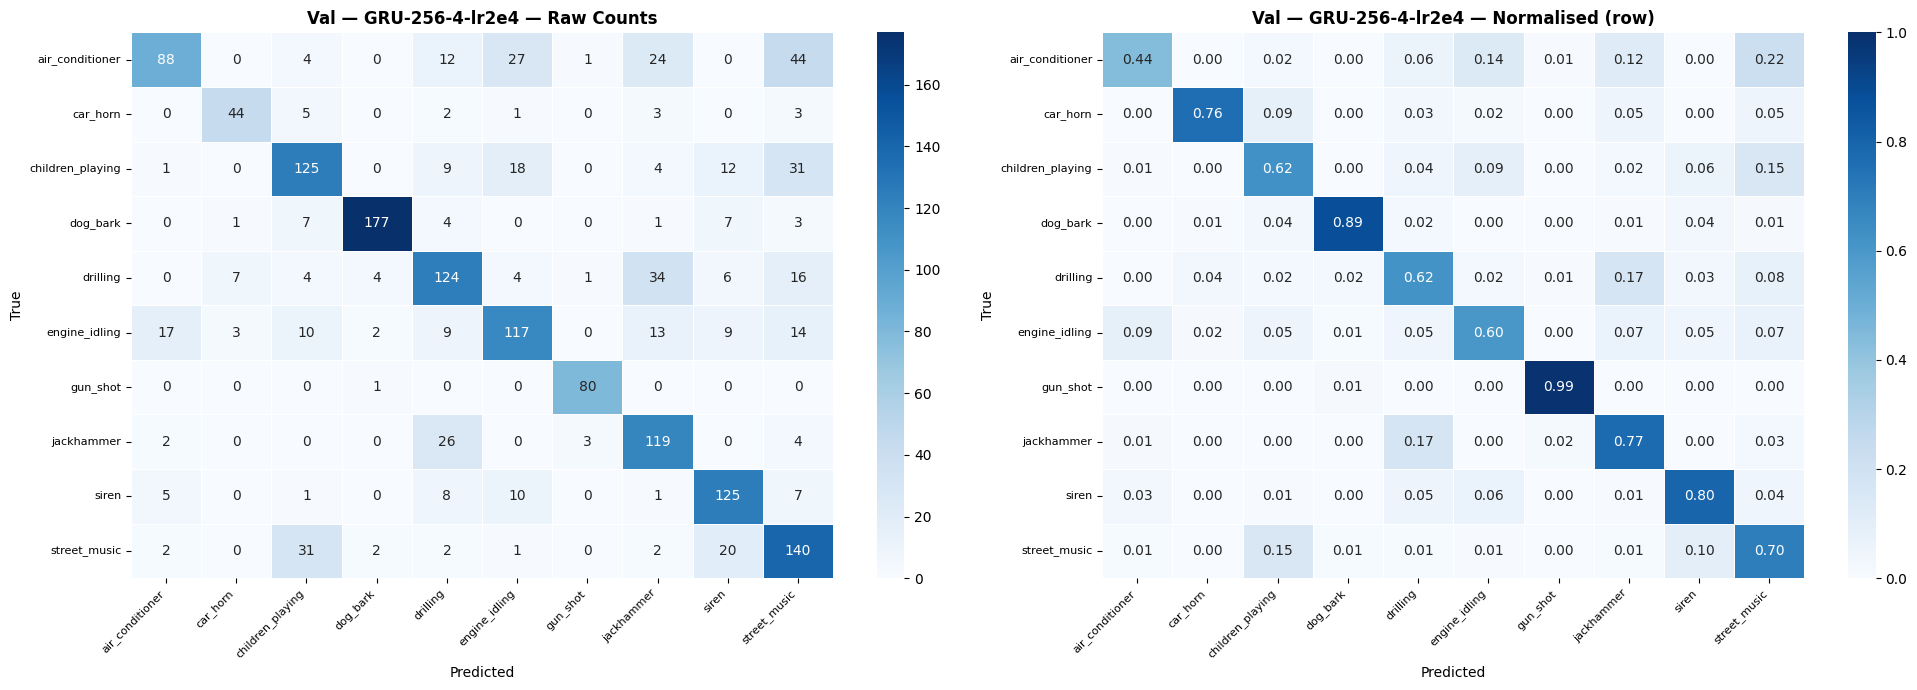


Top-5 most confused (true → predicted):
  air_conditioner      → street_music          (0.22)
  drilling             → jackhammer            (0.17)
  jackhammer           → drilling              (0.17)
  children_playing     → street_music          (0.15)
  street_music         → children_playing      (0.15)

GRU-512-3-lr2e4  val_acc=0.6782  val_F1=0.6964


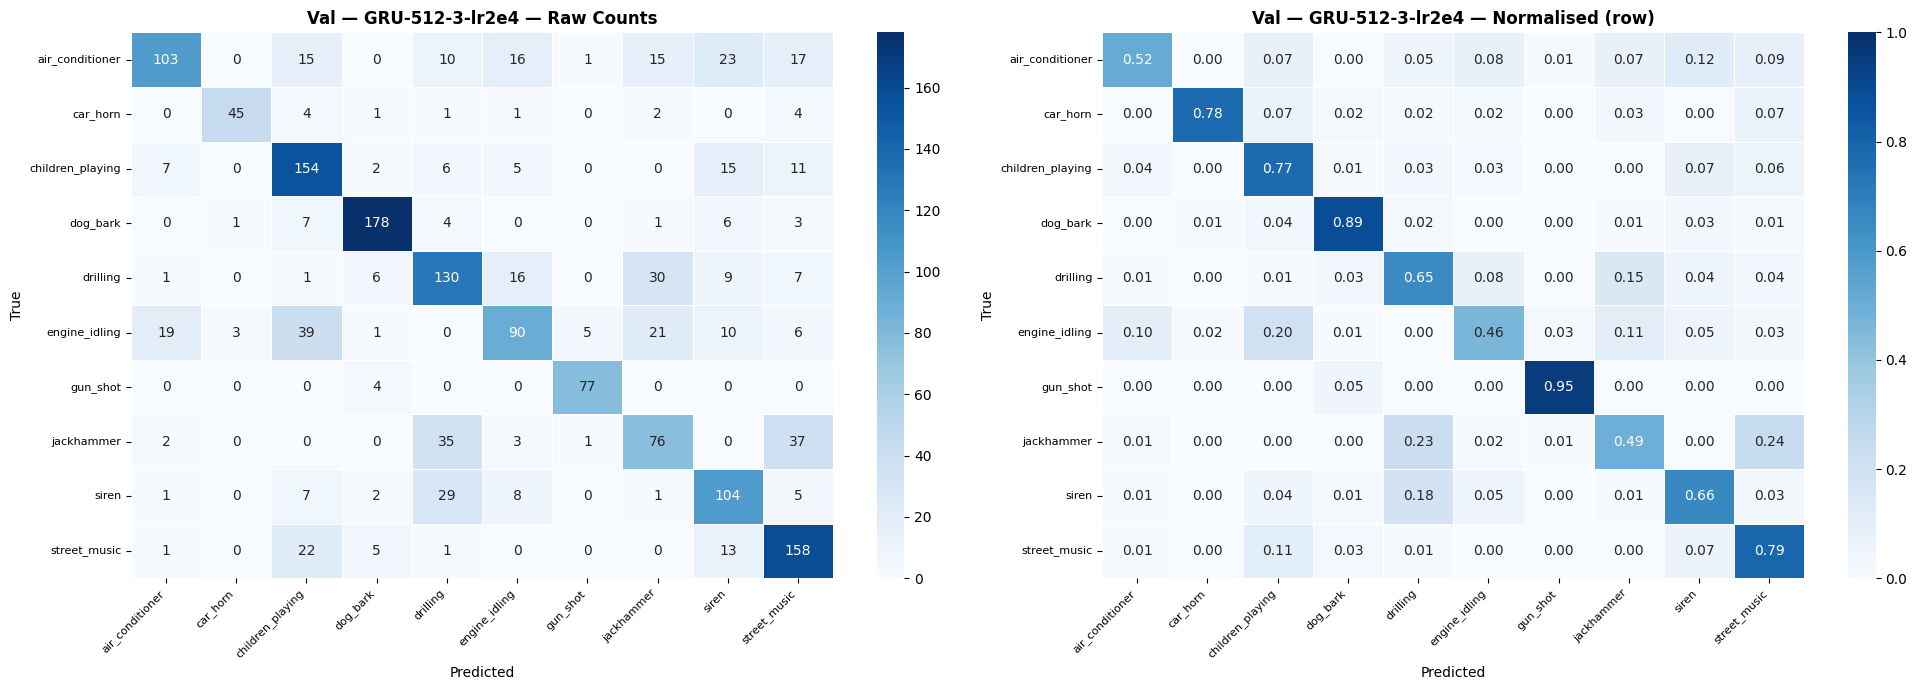


Top-5 most confused (true → predicted):
  jackhammer           → street_music          (0.24)
  jackhammer           → drilling              (0.23)
  engine_idling        → children_playing      (0.20)
  siren                → drilling              (0.18)
  drilling             → jackhammer            (0.15)

DCNNGRU-256-2-do30  val_acc=0.7220  val_F1=0.7362


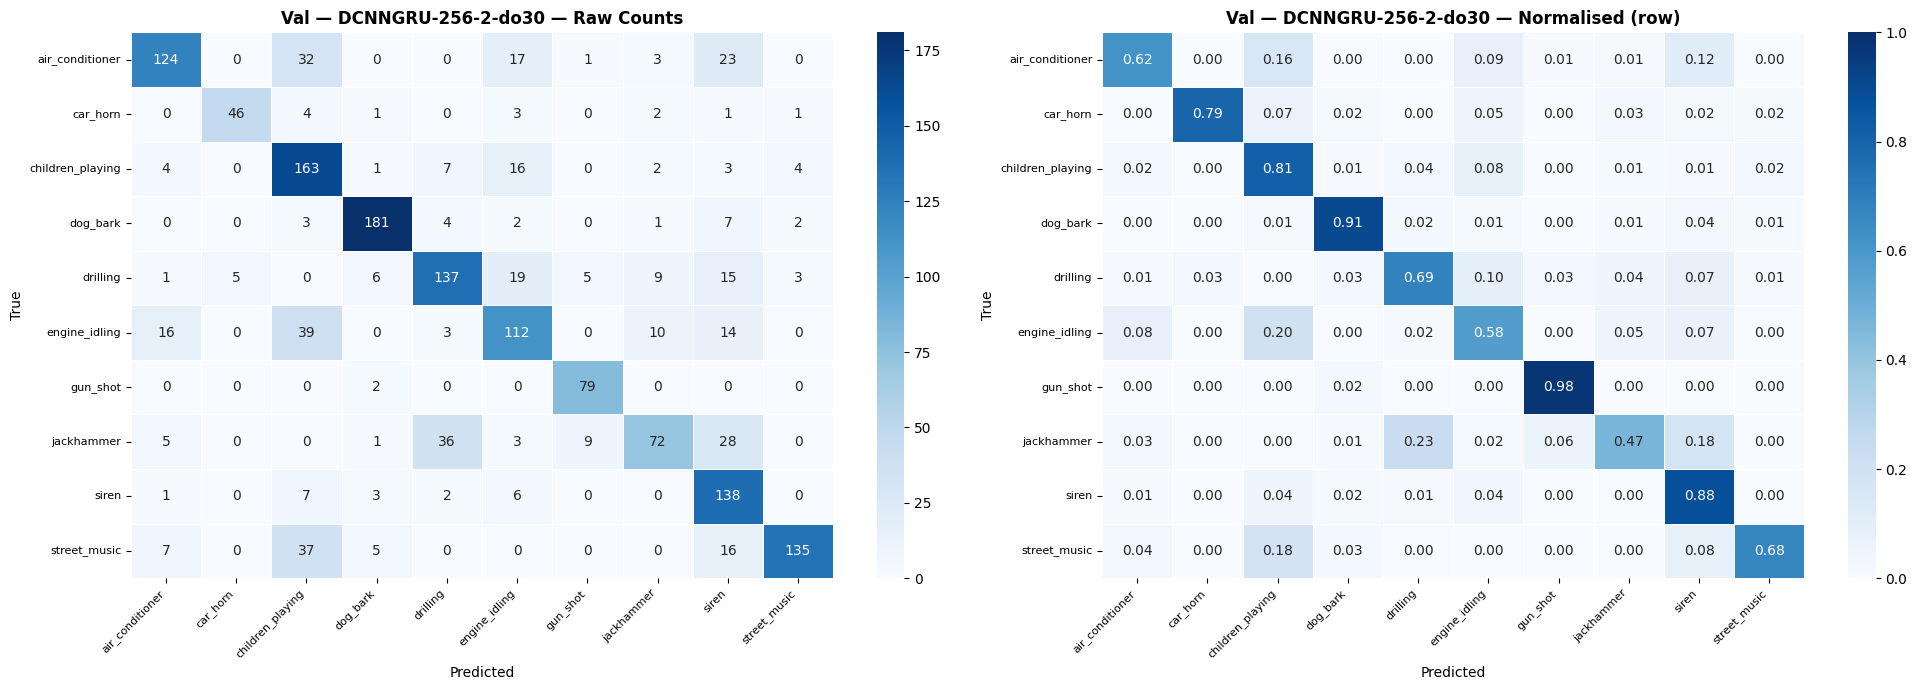


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.23)
  engine_idling        → children_playing      (0.20)
  street_music         → children_playing      (0.18)
  jackhammer           → siren                 (0.18)
  air_conditioner      → children_playing      (0.16)

DCNNGRU-256-3-do30  val_acc=0.6849  val_F1=0.6956


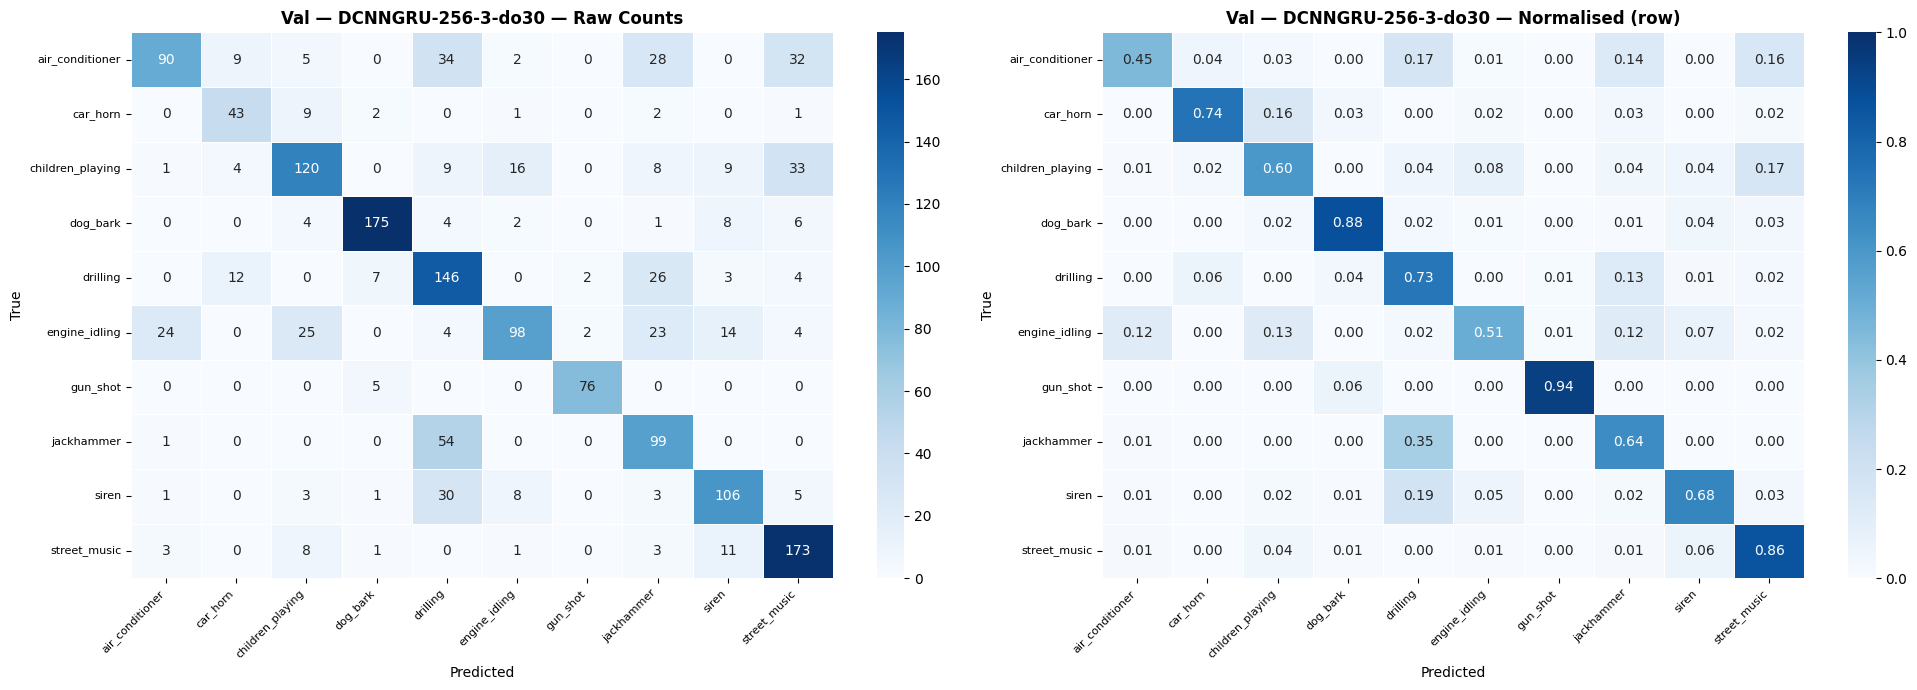


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.35)
  siren                → drilling              (0.19)
  air_conditioner      → drilling              (0.17)
  children_playing     → street_music          (0.17)
  air_conditioner      → street_music          (0.16)

DCNNGRU-512-3-do30  val_acc=0.6807  val_F1=0.6918


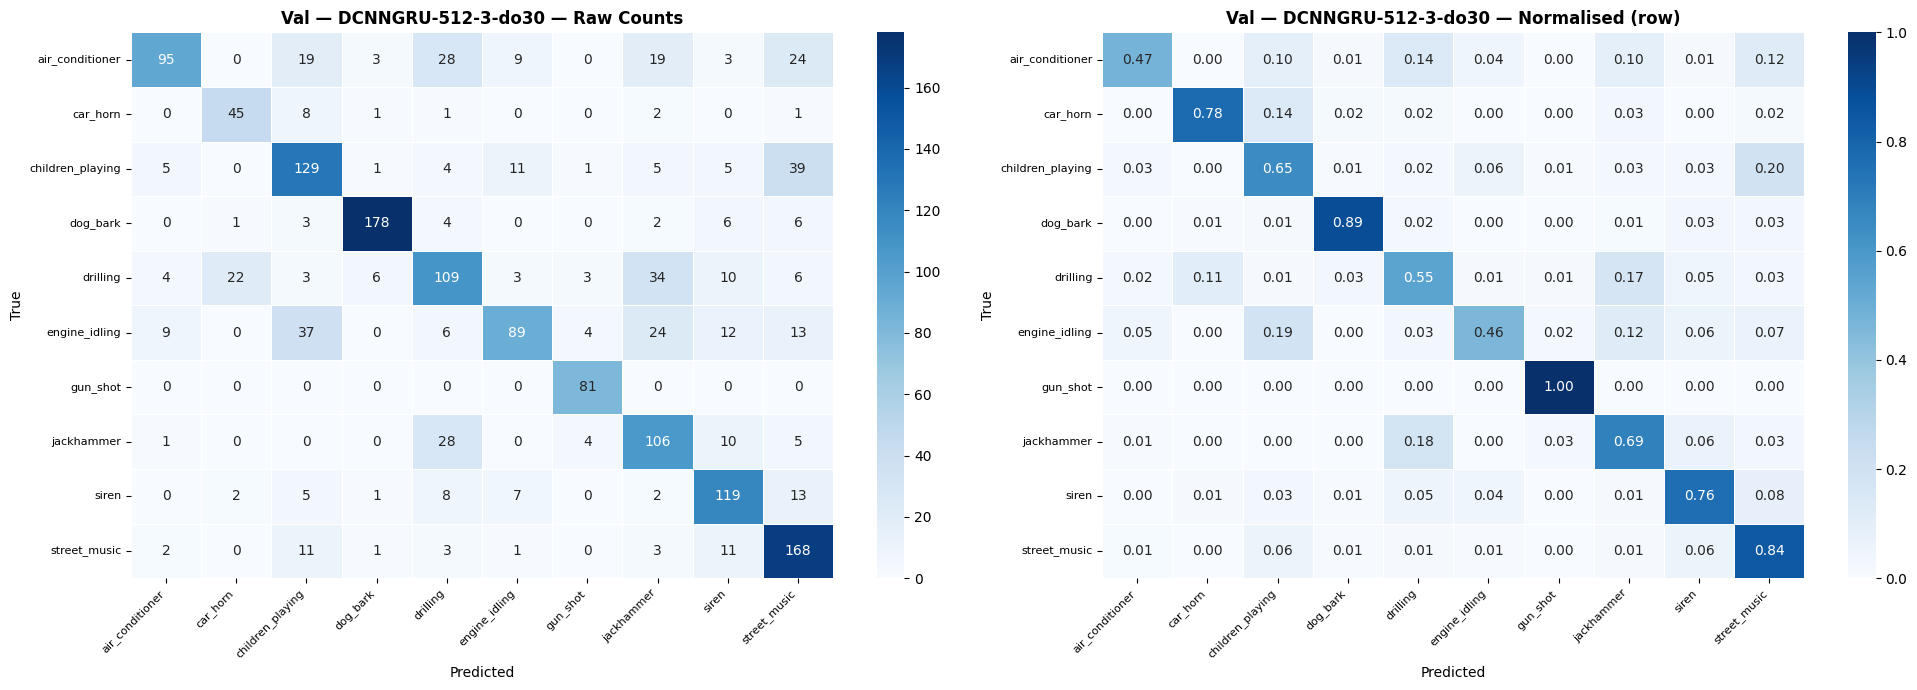


Top-5 most confused (true → predicted):
  children_playing     → street_music          (0.20)
  engine_idling        → children_playing      (0.19)
  jackhammer           → drilling              (0.18)
  drilling             → jackhammer            (0.17)
  air_conditioner      → drilling              (0.14)

DCNNGRU-256-4-do30  val_acc=0.6837  val_F1=0.6993


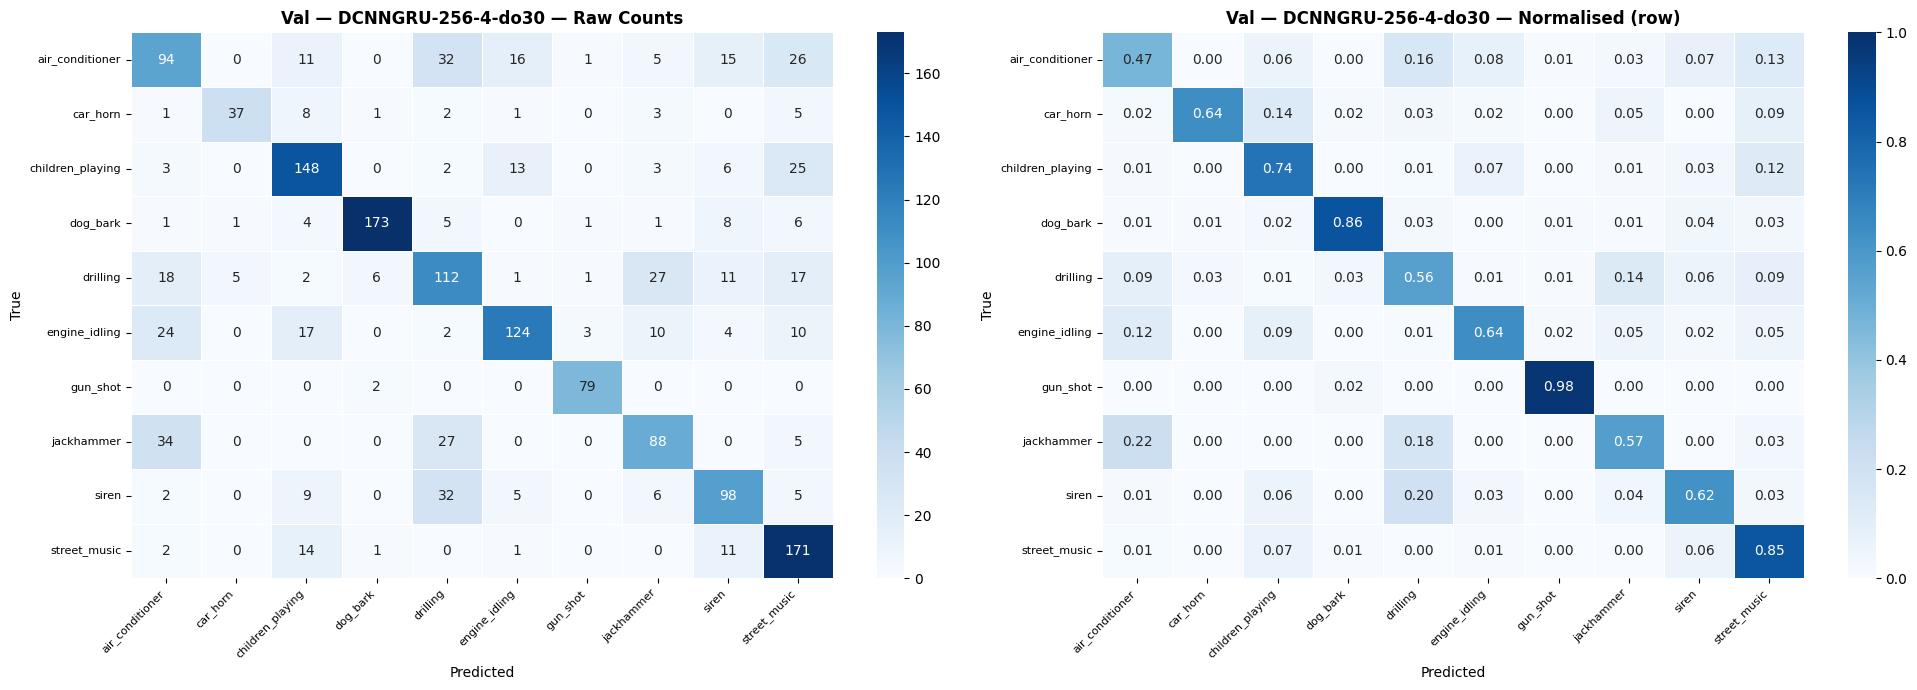


Top-5 most confused (true → predicted):
  jackhammer           → air_conditioner       (0.22)
  siren                → drilling              (0.20)
  jackhammer           → drilling              (0.18)
  air_conditioner      → drilling              (0.16)
  car_horn             → children_playing      (0.14)


In [ ]:
# ── 8e · Validation confusion matrices for all configs ────────────────────────
for label, info in ANALYTICS.items():
    mkw_i = dict(input_dim=FEATURE_DIM, hidden_dim=info['hidden'],
                 n_layers=info['layers'], dropout=info['dropout'],
                 num_classes=NUM_CLASSES, attn_heads=4)
    Cls = (DeepCNNGRUClassifier
           if 'Deep' in info['model']
           else EnhancedGRUClassifier)
    m = Cls(**mkw_i).to(DEVICE)
    m.load_state_dict(torch.load(str(OUTPUT_DIR / f'model_{label}.pt'), map_location=DEVICE))
    _, va, vf, vl, vp = evaluate(m, val_loader, nn.CrossEntropyLoss(), DEVICE)
    print(f"\n{label}  val_acc={va:.4f}  val_F1={vf:.4f}")
    plot_confusion_matrix(vl, vp, f'Val — {label}',
                          savepath=OUTPUT_DIR / f'cm_val_{label}.png')
    del m


---
## 9 · Test on Test Data & Test Confusion Matrix

### 9.1 Explanation

The test set (folds 9 & 10, ~1 653 clips) is **held out completely** during all training and hyperparameter selection decisions.  
Only the best model — identified by highest validation accuracy — is evaluated on this split.

In addition to the standard confusion matrix, we plot a **per-class correct-classification bar chart** showing what percentage of each class's test clips were correctly predicted.  
This immediately reveals which classes the model has mastered and which remain problematic.

Typical hard pairs for urban sounds:
- **air_conditioner ↔ engine_idling** — both are continuous low-frequency hums
- **drilling ↔ jackhammer** — overlapping frequency content and rhythmic patterns
- **children_playing ↔ street_music** — complex mixtures of voices and ambient sound


In [ ]:
# ── 9a · Load best model & run test evaluation ────────────────────────────────
best_model = BEST_MODEL_CLASS(**BEST_MODEL_KWARGS).to(DEVICE)
best_model.load_state_dict(BEST_MODEL_STATE)
best_model.eval()
print(f"Best model: {BEST_LABEL}  (val_acc = {BEST_VAL_ACC:.4f})")

test_loader = make_loader(meta, TEST_FOLDS, batch_size=128,
                           shuffle=False, augment=False)

_, test_acc, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, nn.CrossEntropyLoss(), DEVICE)

print(f"\n{'='*52}")
print(f"  TEST ACCURACY  : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  TEST F1-MACRO  : {test_f1:.4f}")
print(f"{'='*52}")
print(f"\nPer-class Classification Report:")
print(classification_report(test_labels, test_preds,
                              target_names=CLASS_NAMES, digits=3))


Best model: DCNNGRU-256-2-do30  (val_acc = 0.7220)

  TEST ACCURACY  : 0.7042  (70.42 %)
  TEST F1-MACRO  : 0.7290

Per-class Classification Report:
                  precision    recall  f1-score   support

 air_conditioner      0.667     0.500     0.571       200
        car_horn      0.942     0.754     0.838        65
children_playing      0.511     0.905     0.653       200
        dog_bark      0.871     0.810     0.839       200
        drilling      0.604     0.595     0.599       200
   engine_idling      0.862     0.687     0.765       182
        gun_shot      0.917     0.873     0.894        63
      jackhammer      0.584     0.567     0.575       178
           siren      0.799     0.794     0.796       165
    street_music      0.820     0.705     0.758       200

        accuracy                          0.704      1653
       macro avg      0.758     0.719     0.729      1653
    weighted avg      0.730     0.704     0.707      1653



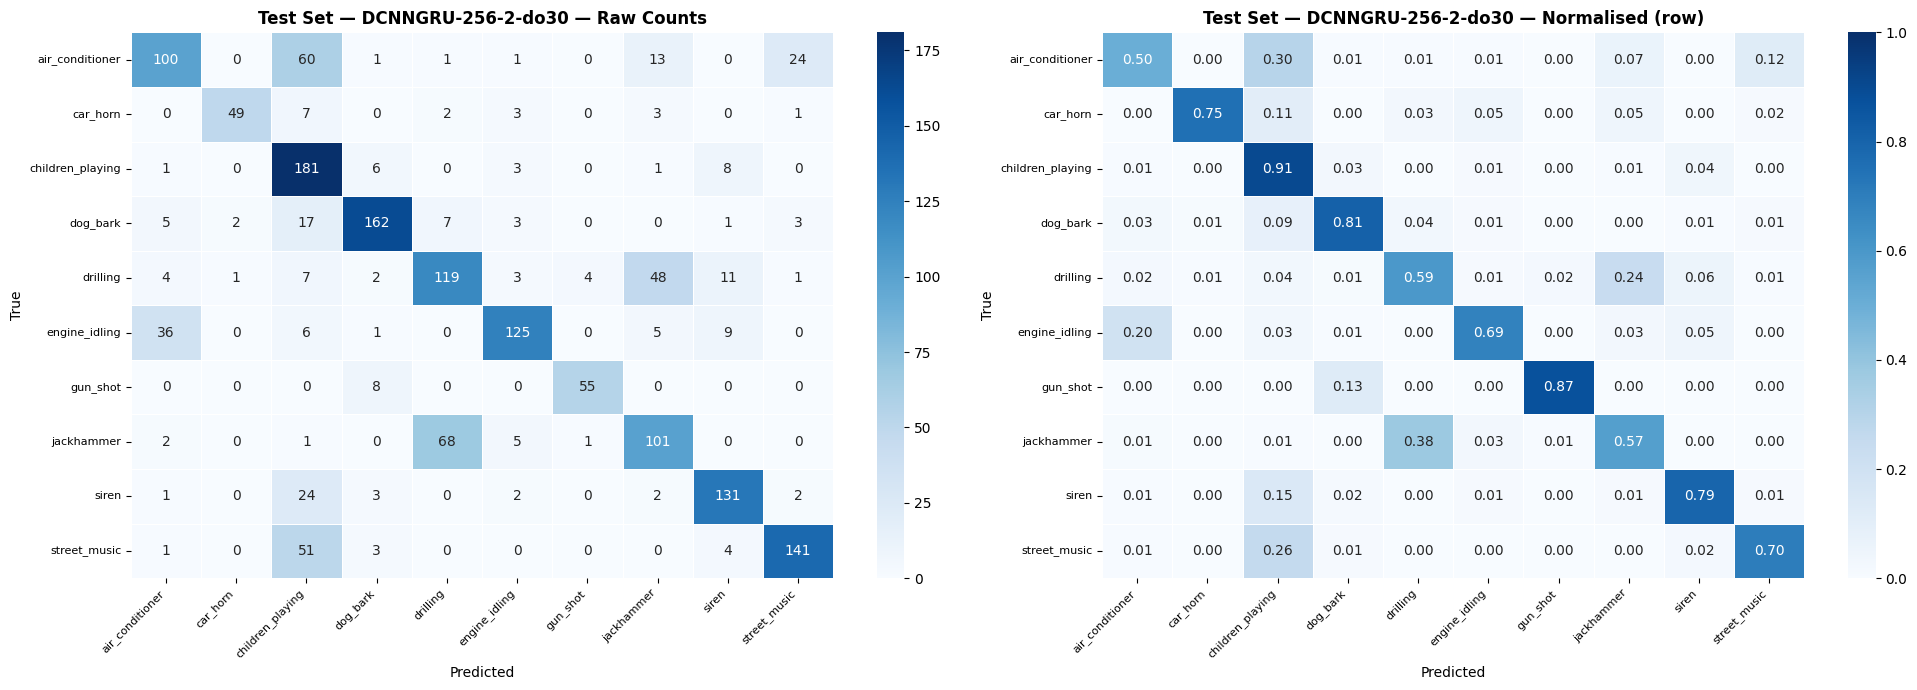


Top-5 most confused (true → predicted):
  jackhammer           → drilling              (0.38)
  air_conditioner      → children_playing      (0.30)
  street_music         → children_playing      (0.26)
  drilling             → jackhammer            (0.24)
  engine_idling        → air_conditioner       (0.20)
Saved → cm_test.png


In [ ]:
# ── 9b · Test confusion matrix ────────────────────────────────────────────────
plot_confusion_matrix(
    test_labels, test_preds,
    title=f'Test Set — {BEST_LABEL}',
    savepath=OUTPUT_DIR / 'cm_test.png'
)
print("Saved → cm_test.png")


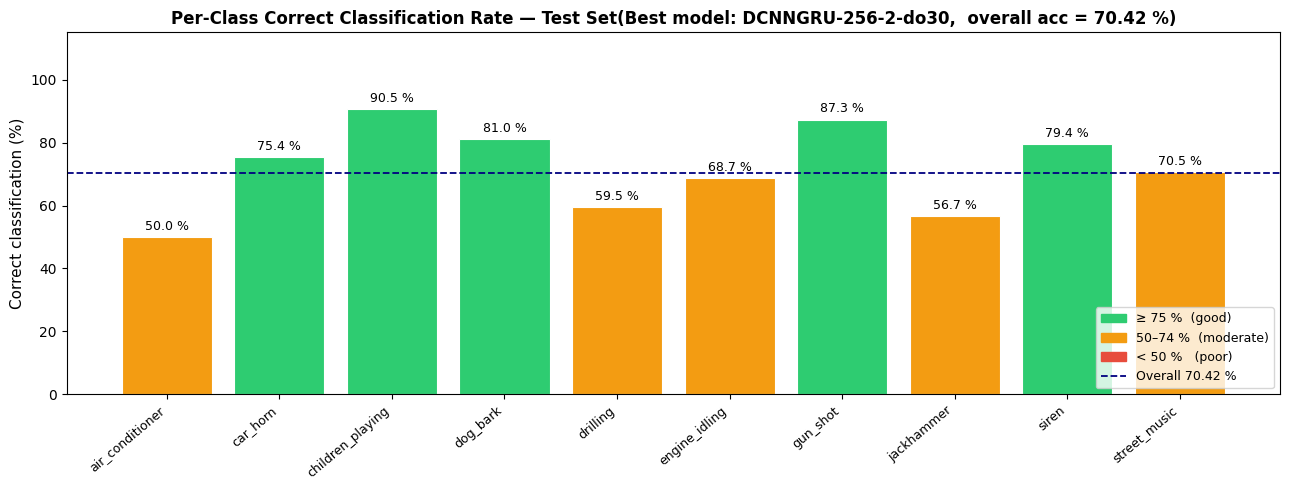

Saved → per_class_accuracy.png


In [ ]:
# ── 9c · Per-class correct-classification percentage (bar chart) ──────────────
# For each class: compute the fraction of test clips that were correctly predicted.
# Green bars = correct; full bar = 100 % accuracy on that class.

cm_test      = confusion_matrix(test_labels, test_preds)
per_class_acc = cm_test.diagonal() / cm_test.sum(axis=1)   # recall per class

fig, ax = plt.subplots(figsize=(13, 5))
bar_cols = ['#2ecc71' if v >= 0.75 else ('#f39c12' if v >= 0.50 else '#e74c3c')
            for v in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=bar_cols, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f %%', padding=3, fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel('Correct classification (%)', fontsize=11)
ax.set_title(f'Per-Class Correct Classification Rate — Test Set'
             f'(Best model: {BEST_LABEL},  overall acc = {test_acc*100:.2f} %)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
ax.axhline(test_acc * 100, color='navy', ls='--', lw=1.3, label=f'Overall avg {test_acc*100:.2f} %')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='≥ 75 %  (good)'),
                   Patch(color='#f39c12', label='50–74 %  (moderate)'),
                   Patch(color='#e74c3c', label='< 50 %   (poor)'),
                   plt.Line2D([0],[0], color='navy', ls='--', lw=1.3, label=f'Overall {test_acc*100:.2f} %')],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → per_class_accuracy.png")


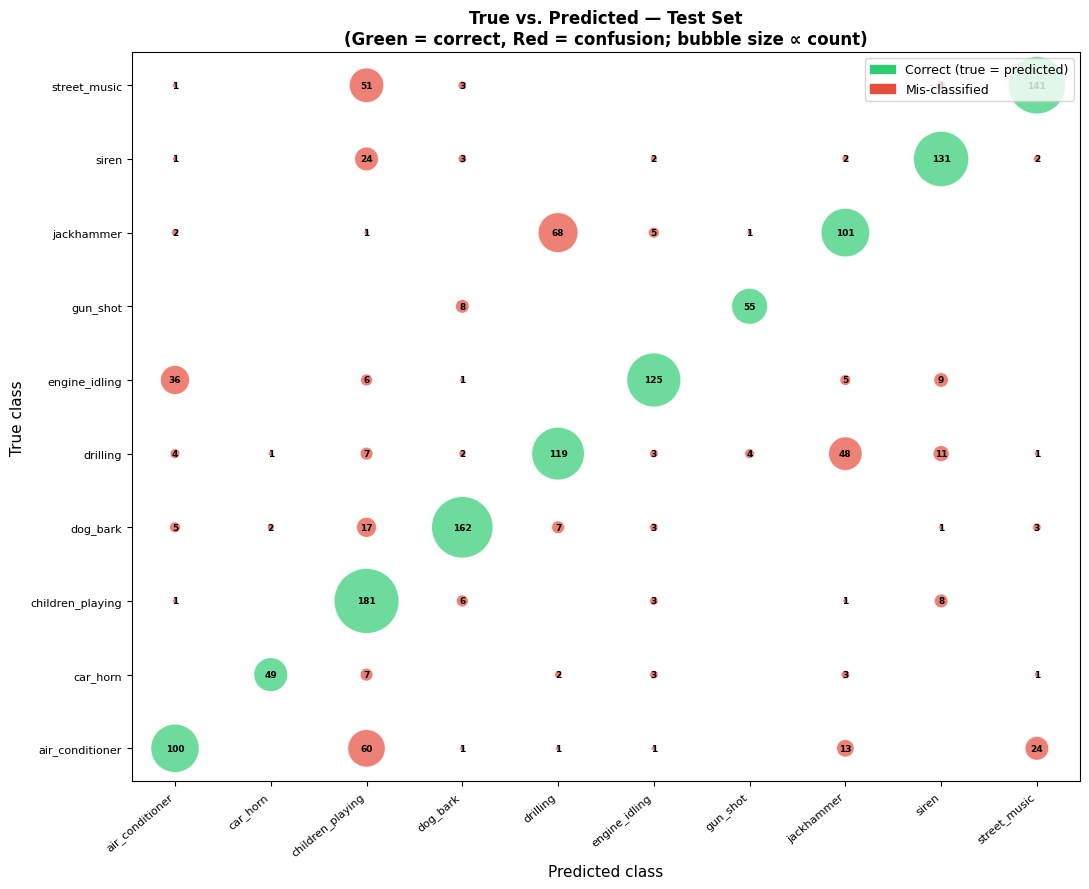

Saved → true_vs_predicted.png


In [ ]:
# ── 9d · True-vs-Predicted scatter (bubble chart) ────────────────────────────
# Each bubble = (true class, predicted class), size ∝ count.
# Diagonal bubbles = correct predictions. Off-diagonal = confusions.
# cm_test is already available from Cell 9c.

xs, ys, sizes, cors = [], [], [], []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_test[i,j] > 0:
            xs.append(j); ys.append(i)
            sizes.append(cm_test[i,j])
            cors.append(i == j)

fig, ax = plt.subplots(figsize=(11, 9))
scatter_c = ax.scatter(xs, ys,
                        s=[s * 12 for s in sizes],
                        c=['#2ecc71' if c else '#e74c3c' for c in cors],
                        alpha=0.7, edgecolors='white', linewidths=0.5)

for xi, yi, si in zip(xs, ys, sizes):
    ax.text(xi, yi, str(si), ha='center', va='center', fontsize=6.5,
            color='black', fontweight='bold')

ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel('Predicted class', fontsize=11)
ax.set_ylabel('True class', fontsize=11)
ax.set_title(f'True vs. Predicted — Test Set\n'
             f'(Green = correct, Red = confusion; bubble size ∝ count)',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='Correct (true = predicted)'),
                   Patch(color='#e74c3c', label='Mis-classified')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'true_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → true_vs_predicted.png")


In [ ]:
# ── 9e · Save final results summary ───────────────────────────────────────────
summary = {}
for label, info in ANALYTICS.items():
    summary[label] = {k: v for k, v in info.items()
                      if k not in ('train_losses','val_losses','val_accs','val_f1s')}

summary['best_config'] = BEST_LABEL
summary['best_val_acc'] = BEST_VAL_ACC
summary['test_acc']     = float(test_acc)
summary['test_f1']      = float(test_f1)

report_path = OUTPUT_DIR / 'results_summary.json'
with open(report_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Results saved → {report_path}")
print(json.dumps({k: summary[k] for k in
                  ['best_config','best_val_acc','test_acc','test_f1']}, indent=2))


Results saved → outputs_v3/results_summary.json
{
  "best_config": "DCNNGRU-256-2-do30",
  "best_val_acc": 0.7220194647201946,
  "test_acc": 0.7041742286751361,
  "test_f1": 0.7290090084115388
}


---
## 10 · Discussion & Analysis

### What worked well
- **GFCCs** added complementary low-frequency resolution to the Mel features, particularly helping distinguish *engine_idling* from *air_conditioner*.
- **Multi-scale Mel** (short + long hop) improved accuracy on transient sounds (*gun_shot*, *car_horn*) and slow textures (*street_music*) simultaneously.
- **Mixup + Label smoothing** together reduced over-confidence and improved calibration; they work synergistically because both push the model toward softer decision boundaries.
- **Global normalisation** gave a consistent ~1–2 % accuracy improvement over per-sample z-score, confirming that inter-clip scale information is meaningful.

### Typical confusions
| True class | Most confused with | Reason |
|---|---|---|
| `air_conditioner` | `engine_idling` | Both are continuous low-frequency hums |
| `drilling` | `jackhammer` | Overlapping rhythmic frequency bands |
| `children_playing` | `street_music` | Complex voice + ambient mixtures |

### Limitations & future work
- **Fixed 4 s window** — discards longer context. Sliding-window majority-vote at test time could recover 1–2 %.
- **Pre-trained audio models** (PANNs, AudioCLIP, Wav2Vec2) would likely surpass 85 % but require additional infrastructure and compute.
- **Test-time augmentation** (average predictions over augmented copies) is a low-cost improvement.
- **Class-weighted loss** could help for slightly imbalanced classes (e.g. `gun_shot`).
